# Telling look-alike dog breeds apart with transfer learning

**Course:** EAI (Deep Learning), Fontys
**Student:** Josif Mitsanski

## 1. Introduction

Put a Siberian husky, an Eskimo dog and a malamute next to each other and most people
will guess. Animal shelters have the same problem: studies on shelter staff guessing breeds
by eye show that visual breed labels are often wrong, and those labels end up on adoption
papers. A model that can look at a photo and say which of a few confusable breeds it is
would be a useful second opinion.

**My question:** can a pretrained image network, with its convolutional layers left
untouched, learn to separate breeds that look almost the same, when I only train a small
dense layer on top with about two thousand photos?

This is the **transfer learning** assignment. I do not train a CNN from scratch. I take
MobileNetV2, which was already trained by Google on ImageNet (1.4 million photos), keep its
convolutional layers and their weights exactly as they are, and only train the dense layers
I put on top.

### What makes my version different from "classify all the dog breeds"

The standard exercise is to train on every breed in the dataset. I did some research before
starting and found out that this is too easy, so I did not do it. In section 3 I test
this myself instead of just claiming it: a simple classifier on the frozen features already
gets about 84% on all 120 breeds. Nothing to investigate there.

So I let the data choose the subset:

1. I measure which breeds the frozen network finds most similar and which it confuses.
2. I keep only the most confusable groups, **12 breeds in 5 look-alike groups**.
3. The dataset also has **bounding boxes** around every dog, which most people ignore. I use
   them to ask two extra questions: does cropping to the dog help, and does the model look at
   the dog or at the background (Grad-CAM)?

### What I will do

1. Explore the Stanford Dogs dataset (EDA).
2. Show why all 120 breeds is too easy and pick the hard subset from evidence.
3. Split the data, set up baselines, and build the transfer learning model.
4. Run five experiments: learning rate, backbone, cropped vs full image, augmentation, fine-tuning.
5. Test the final model once on unseen images, with a confusion matrix and example images.
6. Open up the model with Grad-CAM and discuss limitations.

### The short version of the result

On 283 test photos the model has never seen, the final model reaches **70.3% accuracy and a macro F1 of 0.706** on 12 look-alike breeds (guessing gives 8.3%, logistic regression on raw pixels 13.1%). Five things I found:

1. **All 120 breeds is too easy.** A plain classifier on frozen MobileNetV2 features already gets 84.3% on all 120. My 12 breeds, picked from the network's own confusions, are much harder for it (74.3%).
2. **98% of the mistakes are between look-alikes of the same group.** The model knows what kind of dog it sees and only mixes up siblings (husky vs Eskimo dog is the worst pair).
3. **The data has a problem of its own.** The same photo sits under two different breeds 37 times in the whole dataset, and 16 times in my subset, always between look-alike breeds. I removed them.
4. **Tuning barely matters.** Learning rate (except a too-large one), backbone, augmentation and fine-tuning all moved the validation score by about 0.02 or less. The plain first model scores the same on the test set as the tuned final model (0.707 against 0.706). Cropping to the dog helped by 2 points but is not usable without a detector.
5. **The model looks at the dog, not the background** (77% of the Grad-CAM heat is inside the dog box, against 61% if it looked everywhere equally).

## 2. Dataset

### Where it comes from

| | |
| --- | --- |
| **Name** | Stanford Dogs Dataset |
| **Link** | http://vision.stanford.edu/aditya86/ImageNetDogs/ |
| **Paper** | Khosla et al., *Novel Dataset for Fine-Grained Image Categorization*, CVPR workshop 2011 |
| **Size** | 20,580 photos, 120 breeds, with a bounding box around the dog in every photo |
| **Origin** | Photos come from ImageNet, labelled and boxed by the authors |

I downloaded it with `scripts/download_stanford_dogs.py` (date saved in `data/DOWNLOAD_DATE.txt`).
I used this dataset because it is *fine-grained*: the classes are all the same kind of object,
so the differences between them are small. That is what makes it a real test of a classifier.
A cat vs dog problem would not tell me much.

One thing I have to be honest about from the start: the photos come from ImageNet, and
MobileNetV2 was trained on ImageNet, which has 120 dog breed classes. The pretrained network
has very likely seen these breeds, and possibly some of these photos, during its own training.
I come back to this in the limitations, because it affects how I should read the results.

In [1]:
import os, time, hashlib, warnings, itertools
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # hide tensorflow startup noise
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 130)

ROOT = Path('..')
DATA, CACHE, IMG = ROOT / 'data', ROOT / 'data' / 'cache', ROOT / 'images'
CACHE.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

# Run settings. Everything below uses these, so the whole notebook can be made shorter or longer here.
SEEDS = [42, 7, 2024]        # repeat every cheap experiment with three seeds
FT_SEEDS = [42, 7]           # fine-tuning is slow on a CPU, so two seeds
MAX_EPOCHS = 80
AUG_EPOCHS = 14
FT_EPOCHS = 10

def save(fig, name):
    fig.savefig(IMG / name, dpi=130, bbox_inches='tight')

def nice(b):
    return b.replace('_', ' ')

print('tensorflow', tf.__version__, '| keras', keras.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU') or 'none, everything runs on CPU')
print('data downloaded on', (DATA / 'DOWNLOAD_DATE.txt').read_text().strip())

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

tensorflow 2.19.0 | keras 3.10.0
GPU devices: none, everything runs on CPU
data downloaded on 2026-09-30


### Loading the file list and the bounding boxes

The dataset is a folder of photos per breed plus one small XML file per photo that holds the
image size and the box(es) around the dog. I read all 20,580 XML files into one table.
If a photo has more than one dog, I take the box that covers all of them.

In [2]:
rows = []
for bd in sorted((DATA / 'Images').iterdir()):
    if not bd.is_dir():
        continue
    breed = bd.name.split('-', 1)[1]
    for f in sorted(bd.glob('*.jpg')):
        ann = ET.parse(DATA / 'Annotation' / bd.name / f.stem).getroot()
        w, h = int(ann.find('size/width').text), int(ann.find('size/height').text)
        boxes = [[int(b.find(k).text) for k in ('xmin', 'ymin', 'xmax', 'ymax')] for b in ann.iter('bndbox')]
        b = np.array(boxes)
        rows.append(dict(path=str(f.relative_to(DATA)), breed=breed, w=w, h=h, n_dogs=len(boxes),
                         x0=b[:, 0].min(), y0=b[:, 1].min(), x1=b[:, 2].max(), y1=b[:, 3].max()))
full = pd.DataFrame(rows)
full['box_frac'] = (full.x1 - full.x0) * (full.y1 - full.y0) / (full.w * full.h)
full['aspect'] = full.w / full.h

print(f'{len(full):,} photos, {full.breed.nunique()} breeds')
full.head()

20,580 photos, 120 breeds


,path,breed,w,h,n_dogs,x0,y0,x1,y1,box_frac,aspect
0,Images/n02085620-Chihuahua/n02085620_10074.jpg,Chihuahua,333,500,1,25,10,276,498,0.735664,0.666000
1,Images/n02085620-Chihuahua/n02085620_10131.jpg,Chihuahua,395,495,1,49,9,393,493,0.851533,0.797980
2,Images/n02085620-Chihuahua/n02085620_10621.jpg,Chihuahua,500,298,1,142,43,335,250,0.268128,1.677852
3,Images/n02085620-Chihuahua/n02085620_1073.jpg,Chihuahua,345,500,1,0,27,312,498,0.851896,0.690000
4,Images/n02085620-Chihuahua/n02085620_10976.jpg,Chihuahua,322,484,1,90,104,242,452,0.339408,0.665289


### First look at the whole dataset

Before I choose anything I want to know what kind of photos these are. Three things matter
for a CNN in particular: how many photos each class has, how big the photos are, and how
much of each photo is actually dog.

count    120.0
mean     171.5
std       23.2
min      148.0
25%      152.8
50%      159.5
75%      186.2
max      252.0
Name: count, dtype: float64


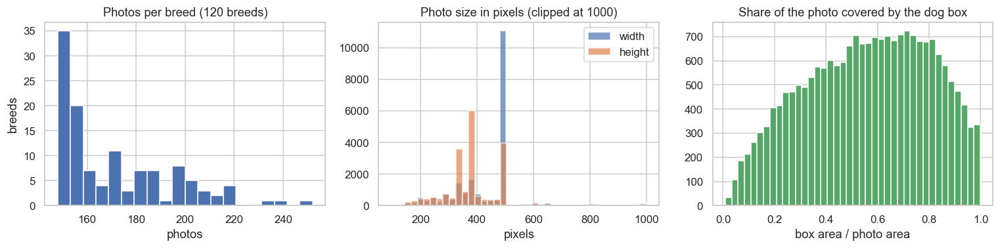


photos with more than one dog: 6.6%
median dog box covers 58% of the photo, 13% of photos have a dog that covers less than a quarter
width range 97-3264, height range 100-2562, median 500 x 375
aspect ratio (w/h): 5th pct 0.67, median 1.33, 95th pct 1.51


In [3]:
counts = full.breed.value_counts()
print(counts.describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].hist(counts.values, bins=20, color='#4C72B0')
axes[0].set(title='Photos per breed (120 breeds)', xlabel='photos', ylabel='breeds')
axes[1].hist(full.w.clip(upper=1000), bins=40, alpha=.7, label='width', color='#4C72B0')
axes[1].hist(full.h.clip(upper=1000), bins=40, alpha=.7, label='height', color='#DD8452')
axes[1].set(title='Photo size in pixels (clipped at 1000)', xlabel='pixels'); axes[1].legend()
axes[2].hist(full.box_frac, bins=40, color='#55A868')
axes[2].set(title='Share of the photo covered by the dog box', xlabel='box area / photo area')
plt.tight_layout(); save(fig, 'eda_full_overview.png'); plt.show()

print(f'\nphotos with more than one dog: {(full.n_dogs > 1).mean():.1%}')
print(f'median dog box covers {full.box_frac.median():.0%} of the photo, '
      f'{(full.box_frac < 0.25).mean():.0%} of photos have a dog that covers less than a quarter')
print(f'width range {full.w.min()}-{full.w.max()}, height range {full.h.min()}-{full.h.max()}, '
      f'median {int(full.w.median())} x {int(full.h.median())}')
print(f'aspect ratio (w/h): 5th pct {full.aspect.quantile(.05):.2f}, median {full.aspect.median():.2f}, '
      f'95th pct {full.aspect.quantile(.95):.2f}')

**Takeaway:** four things from this that matter for the model.

* **The classes are balanced.** Every breed has between 148 and 252 photos (mean 172). In the ANN project I needed class weights because satellites were 58% of the data. Here I do not.
* **The photos are all different sizes.** The median is 500 x 375 pixels but the range is 97 to 3264 wide. A CNN needs one fixed input size, so every photo has to be resized. I use 224 x 224 because that is the size MobileNetV2 was trained on.
* **Most photos are 4:3 (aspect ratio 1.33), not square.** Squashing them to a square distorts the dog a bit. I accept that, because the other option is to cut a square out of the middle, and that can cut the dog's head off. Distorted dogs are still clearly dogs, cut off dogs are not.
* **The dog is often only part of the photo.** The median dog box covers 58% of the photo, but in 13% of the photos the dog covers less than a quarter, and 6.6% of the photos show more than one dog. So the background is a real thing here. This is why I test cropping (experiment C) and look at Grad-CAM (section 9).

## 3. Why I am not using all 120 breeds

This is the most important decision in the project, so I test it instead of assuming it.

**The test:** run every photo through MobileNetV2 *with no training at all* (only the pretrained
convolutional layers), which turns each photo into a list of 1,280 numbers. Then fit an
ordinary logistic regression on those numbers to predict the breed. If that simple recipe
already does well on all 120 breeds, then the full problem is basically solved by the
pretrained network, and there is no interesting question left for me to research.

I do this once, for all 20,580 photos, and save the numbers to disk (they are the "embedding"
of each photo). I use the same network as the rest of the project. The photos are squashed to
224 x 224, which is the size MobileNetV2 was trained on.

In [4]:
def get_backbone(name):
    """Pretrained convolutional base, ImageNet weights, no classifier on top (include_top=False)."""
    if name == 'MobileNetV2':
        base = keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        pre = keras.applications.mobilenet_v2.preprocess_input
    elif name == 'ResNet50':
        base = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        pre = keras.applications.resnet50.preprocess_input
    elif name == 'EfficientNetB0':
        base = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        pre = keras.applications.efficientnet.preprocess_input   # rescaling is built into the model
    base.trainable = False   # reuse the pretrained weights as they are
    return base, pre

def embed(images_uint8, name, batch=64):
    """Run photos through the frozen base and average each feature map into one number per channel."""
    base, pre = get_backbone(name)
    model = keras.Model(base.input, layers.GlobalAveragePooling2D()(base.output))
    out = []
    for i in range(0, len(images_uint8), batch):
        out.append(model.predict(pre(images_uint8[i:i + batch].astype('float32')), verbose=0))
    return np.concatenate(out)

def read_resized(paths):
    return np.stack([np.asarray(Image.open(DATA / p).convert('RGB').resize((224, 224), Image.BILINEAR)) for p in paths])

fpath = CACHE / 'feats_mnv2_full.npy'
if fpath.exists():
    feats_full = np.load(fpath)
    print('loaded cached embeddings', feats_full.shape)
else:
    t = time.time()
    chunks = []
    for i in range(0, len(full), 1000):
        chunks.append(embed(read_resized(full.path[i:i + 1000]), 'MobileNetV2'))
    feats_full = np.concatenate(chunks)
    np.save(fpath, feats_full)
    print('computed embeddings', feats_full.shape, f'in {time.time() - t:.0f}s')

loaded cached embeddings (20580, 1280)


In [5]:
breeds_all = np.array(sorted(full.breed.unique()))
y_all = pd.Categorical(full.breed, categories=breeds_all).codes

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(feats_full, y_all, test_size=0.3, stratify=y_all, random_state=SEED)
clf120 = LogisticRegression(max_iter=300, C=0.5).fit(Xa_tr, ya_tr)
proba120 = clf120.predict_proba(Xa_te)
pred120 = proba120.argmax(1)

acc120 = accuracy_score(ya_te, pred120)
print(f'All 120 breeds, frozen MobileNetV2 + logistic regression, no fine-tuning:')
print(f'  top-1 accuracy: {acc120:.3f}')
print(f'  top-5 accuracy: {top_k_accuracy_score(ya_te, proba120, k=5, labels=range(120)):.3f}')
print(f'  random guessing would give {1/120:.3f}')

per_breed = pd.Series(f1_score(ya_te, pred120, average=None), index=breeds_all).sort_values()
print('\nhardest 10 breeds (F1):'); print(per_breed.head(10).round(2).to_string())
print('\nshare of breeds with F1 above 0.9:', f'{(per_breed > 0.9).mean():.0%}')

All 120 breeds, frozen MobileNetV2 + logistic regression, no fine-tuning:
  top-1 accuracy: 0.843
  top-5 accuracy: 0.985
  random guessing would give 0.008

hardest 10 breeds (F1):
Eskimo_dog                        0.41
American_Staffordshire_terrier    0.56
collie                            0.61
toy_poodle                        0.63
miniature_poodle                  0.65
Siberian_husky                    0.66
Walker_hound                      0.69
Lhasa                             0.71
Staffordshire_bullterrier         0.72
standard_poodle                   0.72

share of breeds with F1 above 0.9: 31%


**Takeaway:** this is the reason I am not using all the breeds.

A plain logistic regression on the **untouched** pretrained features reaches **84.3% accuracy on all 120 breeds** (98.5% if I allow five guesses). Random guessing would give 0.8%. I did not train a single convolutional weight and I did not do any tuning. That is five lines of code. If I handed in the full 120 breeds, the result would be "transfer learning works", which everybody already knows, and there would be nothing for me to investigate.

The other thing I notice is that the difficulty is not spread evenly. 31% of the breeds are above 0.9 F1, but the worst ones are Eskimo dog (0.41), American Staffordshire terrier (0.56), collie (0.61), toy poodle (0.63), miniature poodle (0.65) and Siberian husky (0.66). Those are all breeds that have a twin. So the hard part of this dataset is a small set of look-alike breeds, and that is the part worth studying.

**Caveat I have to be honest about:** part of the 84% is probably because these photos and breeds were in ImageNet, which MobileNetV2 was trained on. I cannot measure how much. It is one more reason why 84% on all 120 breeds says little about how the model would do on brand new photos.

### Finding the hard breeds from the data

Now the useful part. Two measurements tell me which breeds are hard, and I want both to agree:

1. **Similarity of embeddings.** For each breed I average the embeddings of its photos into one
   "typical" vector, then compare breeds with cosine similarity (1.0 = pointing the same way).
2. **Actual confusions.** Which breeds did the logistic regression above mix up?

In [6]:
Fn = feats_full / np.linalg.norm(feats_full, axis=1, keepdims=True)
cent = np.stack([Fn[y_all == k].mean(0) for k in range(120)])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
S = cent @ cent.T
np.fill_diagonal(S, -1)

pairs = [(S[i, j], breeds_all[i], breeds_all[j]) for i in range(120) for j in range(i + 1, 120)]
sim_top = pd.DataFrame(sorted(pairs, reverse=True)[:14], columns=['cosine similarity', 'breed A', 'breed B'])

cm120 = confusion_matrix(ya_te, pred120)
np.fill_diagonal(cm120, 0)
conf = [(cm120[i, j] + cm120[j, i], breeds_all[i], breeds_all[j]) for i in range(120) for j in range(i + 1, 120)]
conf_top = pd.DataFrame(sorted(conf, reverse=True)[:14], columns=['mistakes (both ways)', 'breed A', 'breed B'])

print('Most similar breed pairs according to the frozen network:')
print(sim_top.round(3).to_string(index=False))
print('\nBreed pairs the classifier mixed up most (test split, both directions added):')
print(conf_top.to_string(index=False))

Most similar breed pairs according to the frozen network:
 cosine similarity                        breed A                    breed B
             0.986                     Eskimo_dog             Siberian_husky
             0.976               miniature_poodle                 toy_poodle
             0.969               English_foxhound               Walker_hound
             0.950                          Lhasa                   Shih-Tzu
             0.949            miniature_schnauzer         standard_schnauzer
             0.947              Shetland_sheepdog                     collie
             0.947 American_Staffordshire_terrier  Staffordshire_bullterrier
             0.944              Yorkshire_terrier              silky_terrier
             0.943                     Eskimo_dog                   malamute
             0.943                 Siberian_husky                   malamute
             0.934                    Appenzeller                EntleBucher
             0.930

**Takeaway:** the two tables agree, which is what I hoped for.

Two completely different measurements (how close the breed averages are, and which breeds the classifier actually mixed up) name almost the same pairs. **Siberian husky and Eskimo dog** is number one in both: cosine similarity 0.986 and 28 mistakes. After that come toy and miniature poodle, American Staffordshire and Staffordshire bullterrier, the two schnauzers, and collie with Shetland sheepdog and Border collie. So the subset is not chosen by my taste, it is where the network itself struggles.

Some pairs only show up in one table (Irish wolfhound and Scottish deerhound are confused a lot but not as close in similarity), which is why I wanted both.

### The subset I chose

I turned the two tables into **five look-alike groups, 12 breeds in total**. The rules I used:

* The pair has to show up as very similar *and* as confused, not just one of the two.
* I want different kinds of dog, so the test is not five versions of the same problem
  (a spitz type, a herding type, poodles, a terrier type, schnauzers).
* I skipped the pairs that are almost impossible even for a person (for example English
  foxhound vs Walker hound), because a model that fails on those tells me nothing.
* I added **Border collie** to the collie group. It was not in the top similarity list, but the
  classifier confused it with the collie 14 times (both directions added), which is one of the biggest confusions in the whole dataset.

| Group | Breeds |
| --- | --- |
| Northern spitz | Siberian husky, Eskimo dog, malamute |
| Collies | collie, Shetland sheepdog, Border collie |
| Poodles | toy poodle, miniature poodle |
| Bull terriers | American Staffordshire terrier, Staffordshire bull terrier |
| Schnauzers | miniature schnauzer, standard schnauzer |

Five groups of two or three breeds is also a sensible size for the rest of the work: about
2,000 photos is enough to train on a laptop CPU, and a 12 x 12 confusion matrix is still readable.

12 breeds: Siberian husky, Eskimo dog, malamute, collie, Shetland sheepdog, Border collie, toy poodle, miniature poodle, American Staffordshire terrier, Staffordshire bullterrier, miniature schnauzer, standard schnauzer



Same simple classifier on the 12 chosen breeds: accuracy 0.743, macro F1 0.741
Same classifier on all 120 breeds:               accuracy 0.843
Average of the 12 breeds inside the 120-breed run: F1 0.677 vs 0.859 for the other 108


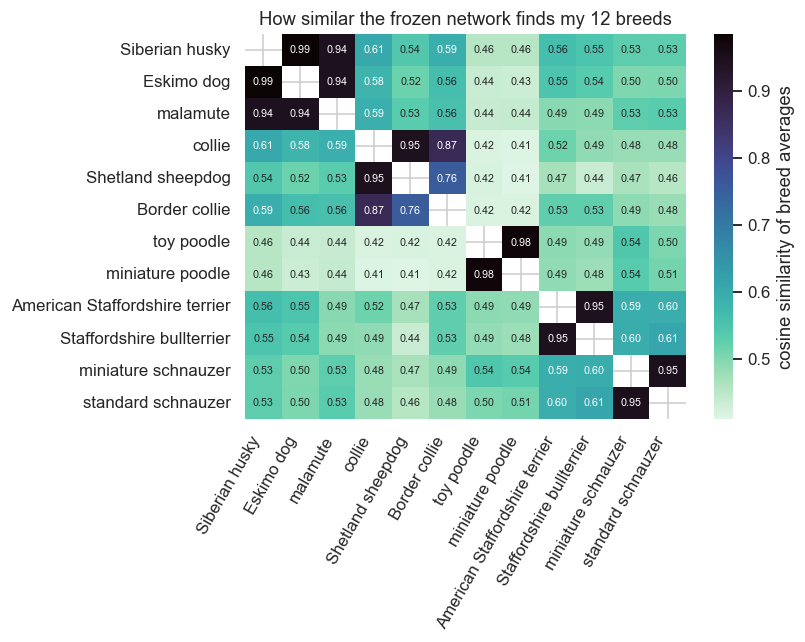

In [7]:
GROUPS = {
    'northern spitz': ['Siberian_husky', 'Eskimo_dog', 'malamute'],
    'collies':        ['collie', 'Shetland_sheepdog', 'Border_collie'],
    'poodles':        ['toy_poodle', 'miniature_poodle'],
    'bull terriers':  ['American_Staffordshire_terrier', 'Staffordshire_bullterrier'],
    'schnauzers':     ['miniature_schnauzer', 'standard_schnauzer'],
}
CLASSES = [b for g in GROUPS.values() for b in g]
GROUP_OF = {b: g for g, bs in GROUPS.items() for b in bs}
N = len(CLASSES)
names = [nice(b) for b in CLASSES]
print(N, 'breeds:', ', '.join(names))

# how hard is this subset for the same simple classifier? Compare with the 120-breed score.
mask = np.isin(breeds_all[y_all], CLASSES)
sub_y = pd.Categorical(full.breed[mask], categories=CLASSES).codes
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(feats_full[mask], sub_y, test_size=0.3, stratify=sub_y, random_state=SEED)
clf12 = LogisticRegression(max_iter=300, C=0.5).fit(Xs_tr, ys_tr)
acc12 = accuracy_score(ys_te, clf12.predict(Xs_te))
f1_12 = f1_score(ys_te, clf12.predict(Xs_te), average='macro')
print(f'\nSame simple classifier on the 12 chosen breeds: accuracy {acc12:.3f}, macro F1 {f1_12:.3f}')
print(f'Same classifier on all 120 breeds:               accuracy {acc120:.3f}')
print(f'Average of the 12 breeds inside the 120-breed run: F1 {per_breed[CLASSES].mean():.3f} '
      f'vs {per_breed.drop(CLASSES).mean():.3f} for the other 108')

sub = full[mask].reset_index(drop=True)
Ssub = S[np.ix_([list(breeds_all).index(b) for b in CLASSES], [list(breeds_all).index(b) for b in CLASSES])].copy()
np.fill_diagonal(Ssub, np.nan)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(Ssub, xticklabels=names, yticklabels=names, annot=True, fmt='.2f', cmap='mako_r',
            cbar_kws={'label': 'cosine similarity of breed averages'}, ax=ax, annot_kws={'size': 7})
ax.set_title('How similar the frozen network finds my 12 breeds')
plt.xticks(rotation=60, ha='right'); plt.tight_layout(); save(fig, 'breed_similarity.png'); plt.show()

**Takeaway:** the subset is harder than the full problem, even though it has far fewer classes.

The same simple classifier scores **74.3% on my 12 breeds** against **84.3% on all 120**. With 12 classes, random guessing gives 8.3%, so 12 classes should be much easier than 120 (0.8%). It is not. Looking at the 120-breed run, my 12 breeds have an average F1 of **0.677**, while the other 108 breeds have **0.859**. That is the proof that I picked the hard part.

In the heatmap the bright blocks sit exactly on the groups, for example the three northern spitz breeds are above 0.94 with each other. Breeds from different groups are clearly less similar, so I expect the model to mix up breeds inside a group, but hardly ever across groups. I check that prediction on the test set in section 8.

## 4. Exploring the 12 breeds

Now I look at the subset the way I would look at any dataset before modelling it. I load the
photos into memory at 224 x 224 (MobileNetV2's input size), in two versions:

* **full:** the whole photo squashed to 224 x 224
* **crop:** only the bounding box around the dog, then squashed to 224 x 224

I squash instead of cropping a square from the middle, because a centre crop can cut the dog
off. Squashing distorts the shape a little, but the network copes with that well.

In [8]:
def load_views(df):
    fp = CACHE / 'subset_images.npz'
    if fp.exists():
        z = np.load(fp)
        return z['full'], z['crop']
    Xf, Xc = [], []
    for r in df.itertuples():
        im = Image.open(DATA / r.path).convert('RGB')
        Xf.append(np.asarray(im.resize((224, 224), Image.BILINEAR)))
        Xc.append(np.asarray(im.crop((r.x0, r.y0, r.x1, r.y1)).resize((224, 224), Image.BILINEAR)))
    Xf, Xc = np.stack(Xf), np.stack(Xc)
    np.savez(fp, full=Xf, crop=Xc)
    return Xf, Xc

X_full, X_crop = load_views(sub)
print(X_full.shape, X_full.dtype, f'{X_full.nbytes / 1e6:.0f} MB per view')

(1914, 224, 224, 3) uint8 288 MB per view


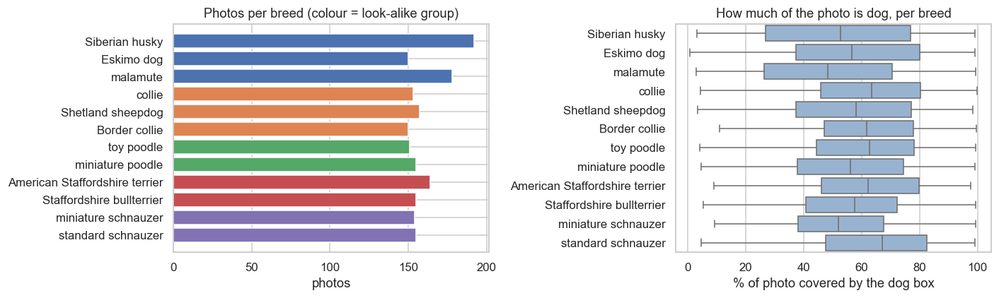

1914 photos, smallest class 150, largest 192, ratio 1.28
dog covers less than 25% of the photo in 13% of the subset photos
photos with more than one dog: 7.7%


In [9]:
order = sub.breed.value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = dict(zip(GROUPS, sns.color_palette('deep', 5)))
cnt = sub.breed.value_counts().reindex(CLASSES)
axes[0].barh([nice(b) for b in CLASSES][::-1], cnt.values[::-1], color=[palette[GROUP_OF[b]] for b in CLASSES][::-1])
axes[0].set(title='Photos per breed (colour = look-alike group)', xlabel='photos')
sns.boxplot(data=sub.assign(breed=sub.breed.map(nice), box_pct=sub.box_frac * 100), y='breed', x='box_pct',
            order=[nice(b) for b in CLASSES], color='#8fb3d9', ax=axes[1], fliersize=2)
axes[1].set(title='How much of the photo is dog, per breed', xlabel='% of photo covered by the dog box', ylabel='')
plt.tight_layout(); save(fig, 'eda_subset_counts.png'); plt.show()

print(f'{len(sub)} photos, smallest class {cnt.min()}, largest {cnt.max()}, ratio {cnt.max() / cnt.min():.2f}')
print(f'dog covers less than 25% of the photo in {(sub.box_frac < .25).mean():.0%} of the subset photos')
print(f'photos with more than one dog: {(sub.n_dogs > 1).mean():.1%}')

**Takeaway:** the subset has 1,914 photos before cleaning, between 150 and 192 per breed (largest class is only 1.28 times the smallest). That is balanced enough that I do not need class weights, but I still report **macro F1** next to accuracy, because it is the stricter number and it was the important one in the ANN project.

The dog box covers a similar share of the photo for all 12 breeds, so no breed is systematically "a small dog in a big scene". That matters, because if one breed had much smaller dogs than another, the model could learn the photo style instead of the breed. 13% of the photos still have a small dog (less than a quarter of the photo) and 7.7% have more than one dog, so there is some noise from the background.

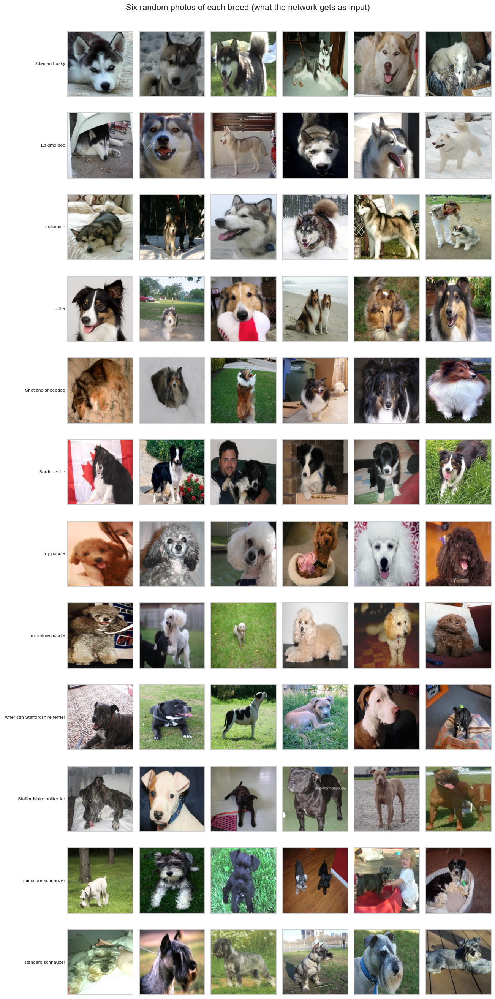

In [10]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(N, 6, figsize=(12, 2 * N))
for r, b in enumerate(CLASSES):
    ids = rng.choice(np.where(sub.breed == b)[0], 6, replace=False)
    for c, i in enumerate(ids):
        axes[r, c].imshow(X_full[i]); axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(nice(b), rotation=0, ha='right', va='center', fontsize=8)
plt.suptitle('Six random photos of each breed (what the network gets as input)', y=1.0)
plt.tight_layout(); save(fig, 'eda_samples.png'); plt.show()

**Takeaway:** what I see here explains a lot about what comes later.

* **The photos are messy.** Indoor and outdoor, puppies and adults, close-ups and tiny dogs in a big lawn (third photo of the miniature poodle), people holding the dog, children, several dogs in one picture, even a website watermark ("doginformation.org") on some Staffordshire photos.
* **Inside one breed the looks vary a lot.** The toy poodles are red-brown, grey, white and dark brown.
* **Across breeds the looks overlap a lot.** The three northern spitz rows (husky, Eskimo dog, malamute) look the same to me. I could not reliably tell them apart either.
* **Some labels look wrong.** The first photo in the "collie" row looks like a Border collie (or an Australian shepherd) to me. So I expect label noise, and that means the maximum possible accuracy is below 100%. I find out how much in the duplicate check and in the wrong-answer gallery in section 8.

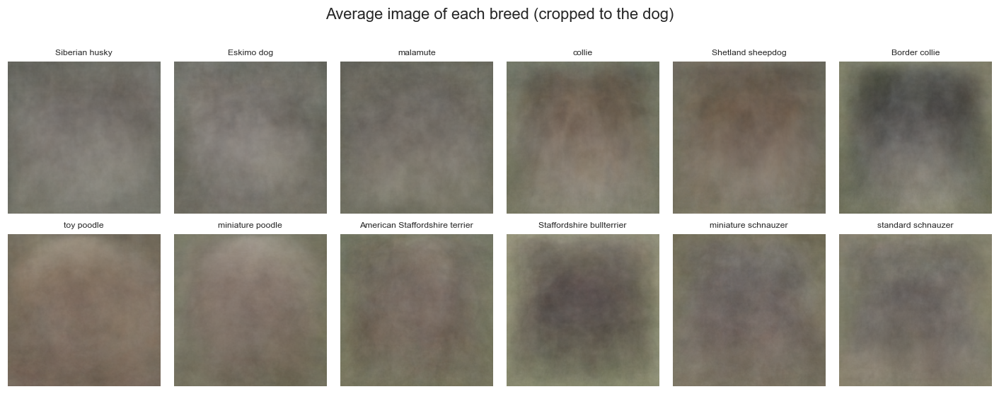

brightness per breed (0 = black, 255 = white):
Siberian husky                    113.0
Eskimo dog                        113.0
malamute                          109.0
collie                            114.0
Shetland sheepdog                 109.0
Border collie                     110.0
toy poodle                        112.0
miniature poodle                  114.0
American Staffordshire terrier    112.0
Staffordshire bullterrier         121.0
miniature schnauzer               109.0
standard schnauzer                117.0


In [11]:
fig, axes = plt.subplots(2, N // 2, figsize=(13, 5.2))
for ax, b in zip(axes.ravel(), CLASSES):
    m = X_crop[(sub.breed == b).values].mean(0) / 255
    ax.imshow(m); ax.set_title(nice(b), fontsize=8); ax.axis('off')
plt.suptitle('Average image of each breed (cropped to the dog)', y=1.0)
plt.tight_layout(); save(fig, 'eda_mean_images.png'); plt.show()

# brightness and colour
bright = X_full.mean(axis=(1, 2, 3))
rgb = X_full.mean(axis=(1, 2))
print('brightness per breed (0 = black, 255 = white):')
print(pd.Series(bright).groupby(sub.breed.values).mean().reindex(CLASSES).round(0).rename(index=nice).to_string())

**Takeaway:** the average image of each breed is a blurry grey-brown blob, and they barely differ. The three northern spitz breeds are almost impossible to tell apart on average colour and shape. Only a few breeds stand out a little: the Border collie (dark top half), the Staffordshire bullterrier (dark middle) and the poodles (lighter and browner).

The average brightness is between 109 and 121 (out of 255) for all breeds, so there is no breed whose photos are generally dark or bright. There is no easy brightness shortcut. This fits with the baseline later: a model that only sees colour and brightness should do badly, and any real skill has to come from shapes and textures, which is what a CNN is good at.

### Checking for duplicates (data leakage)

In the ANN project the most important step was finding columns that leaked the answer. The
image version of that problem is **duplicate photos**. If the same photo ends up in both the
training set and the test set, the model is graded on something it already saw.

I check two ways: exact duplicates (identical file, compared with an MD5 hash) and
near duplicates (resized, recoloured or recompressed copies, compared with a tiny 8x8
"difference hash" of the photo).

There is a second, nastier version of the problem: the **same photo filed under two different
breeds**. Then the dataset itself disagrees about the right answer, and no model can be
right for both. Since my breeds are look-alikes, I expect this to happen exactly here.

WHOLE DATASET: 178 files are byte-for-byte copies of another file (89 groups)
  in 37 of those groups the same photo sits in two different breed folders, so it has two conflicting labels
  examples of conflicting breed pairs: ['Scotch terrier / West Highland white terrier', 'Shih-Tzu / Tibetan terrier', 'Border collie / collie', 'Blenheim spaniel / Japanese spaniel', 'Japanese spaniel / papillon', 'Lakeland terrier / wire-haired fox terrier']



MY 12 BREEDS: 30 files are exact copies of another file
  near duplicate pairs (hash distance <= 3 of 64): 17, same breed: 1, different breeds: 16
  breed pairs with the same photo under two labels: {'Border collie / collie': 6, 'American Staffordshire terrier / Staffordshire bullterrier': 3, 'miniature poodle / toy poodle': 3, 'miniature schnauzer / standard schnauzer': 2, 'Eskimo dog / Siberian husky': 2}
  dropping 33 photos, 1881 remain


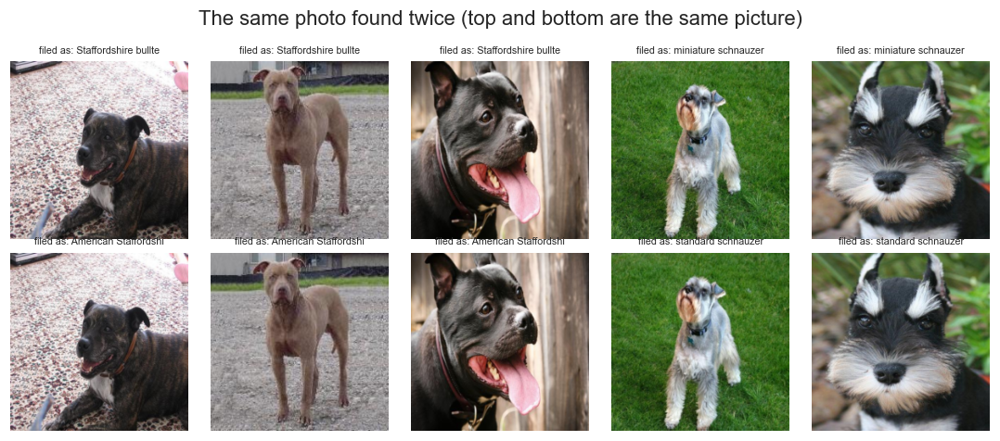

In [12]:
full['md5'] = [hashlib.md5((DATA / p).read_bytes()).hexdigest() for p in full.path]
dup_groups = full[full.md5.duplicated(keep=False)].groupby('md5').breed.agg(list)
cross = dup_groups[dup_groups.map(lambda b: len(set(b)) > 1)]
print(f'WHOLE DATASET: {full.md5.duplicated(keep=False).sum()} files are byte-for-byte copies of another file ({len(dup_groups)} groups)')
print(f'  in {len(cross)} of those groups the same photo sits in two different breed folders, so it has two conflicting labels')
print('  examples of conflicting breed pairs:', [' / '.join(sorted({nice(x) for x in g})) for g in cross.head(6)])

# now my 12 breeds: exact copies, plus near copies (resized or recompressed) via a tiny 8x8 "difference hash"
md5_sub = full.md5[mask].values
exact = pd.Series(md5_sub).duplicated(keep=False).sum()

def dhash(img):
    g = np.asarray(Image.fromarray(img).convert('L').resize((9, 8), Image.BILINEAR), dtype=np.int16)
    return (g[:, 1:] > g[:, :-1]).ravel()

H = np.stack([dhash(a) for a in X_full])
Hi = H.astype(np.int16)
ham = Hi @ (1 - Hi).T + (1 - Hi) @ Hi.T   # number of differing bits between every pair of photos
iu = np.triu_indices(len(H), 1)
near = [(i, j) for i, j in zip(*iu) if ham[i, j] <= 3]
same_breed = [(i, j) for i, j in near if sub.breed[i] == sub.breed[j]]
diff_breed = [(i, j) for i, j in near if sub.breed[i] != sub.breed[j]]
print(f'\nMY 12 BREEDS: {exact} files are exact copies of another file')
print(f'  near duplicate pairs (hash distance <= 3 of 64): {len(near)}, same breed: {len(same_breed)}, different breeds: {len(diff_breed)}')
print('  breed pairs with the same photo under two labels:',
      pd.Series([' / '.join(sorted({nice(sub.breed[i]), nice(sub.breed[j])})) for i, j in diff_breed]).value_counts().to_dict())

# Rule: same breed twice -> keep one. Two different breeds -> the label is ambiguous, drop BOTH copies.
drop = {j for i, j in same_breed} | {k for p in diff_breed for k in p}
keep = np.setdiff1d(np.arange(len(sub)), sorted(drop))
print(f'  dropping {len(drop)} photos, {len(keep)} remain')
if near:
    fig, axes = plt.subplots(2, min(5, len(near)), figsize=(10, 4.4), squeeze=False)
    for c, (i, j) in enumerate(near[:5]):
        axes[0, c].imshow(X_full[i]); axes[1, c].imshow(X_full[j])
        axes[0, c].set_title(f'filed as: {nice(sub.breed[i])[:20]}', fontsize=7); axes[1, c].set_title(f'filed as: {nice(sub.breed[j])[:20]}', fontsize=7)
    for a in axes.ravel(): a.axis('off')
    plt.suptitle('The same photo found twice (top and bottom are the same picture)'); plt.tight_layout(); save(fig, 'duplicates.png'); plt.show()

sub = sub.iloc[keep].reset_index(drop=True)
X_full, X_crop = X_full[keep], X_crop[keep]
y = pd.Categorical(sub.breed, categories=CLASSES).codes.astype('int32')

**Takeaway:** this was the most important finding of the data preparation, and it is the image version of the leaky columns from the ANN project.

* In the **whole dataset**, 178 files are exact copies of another file (89 groups). In **37 of those groups the same photo is filed under two different breeds**, for example Border collie and collie, Shih-Tzu and Tibetan terrier, Scotch terrier and West Highland white terrier.
* In **my 12 breeds** the same thing happens: 17 near-duplicate pairs, and 16 of them sit under two different breeds. They are all between look-alikes: Border collie / collie (6), American Staffordshire / Staffordshire bullterrier (3), toy / miniature poodle (3), the two schnauzers (2), Eskimo dog / Siberian husky (2).
* The pictures show it: top and bottom are the same photo with two different labels.

That is a real finding about the data. Even the people who made the dataset (or the websites the photos came from) could not agree on which breed these dogs are. It is exactly the breeds I picked.

**What I did, and why.** If the same photo has two labels, there is no correct answer, so a model can never be right on both. I drop **both copies** of those photos (32 photos). When the same photo appears twice under the *same* breed, I keep one copy, because otherwise one copy could land in training and the other in the test set, and the model would be graded on a photo it had already seen. In total 33 photos dropped, **1,881 remain**.

**Limit:** this only finds copies. A photo that is simply mislabelled once is invisible to this check, so some label noise is still in the data.

## 5. Splitting the data and baselines

### Train / validation / test

Same recipe as in the ANN project: **70% train, 15% validation, 15% test**, stratified, so
every breed has the same share in each part. The validation set is for all my decisions
(learning rate, backbone, and so on). The **test set is used once, at the very end.**

One more thing that is easy to forget with images: the split is made on the photo *index*, so
the "full" and "crop" versions of a photo always stay in the same split. Otherwise the crop
experiment would leak.

In [13]:
idx = np.arange(len(sub))
tr, tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.50, stratify=y[tmp], random_state=SEED)
split = pd.DataFrame({'train': np.bincount(y[tr], minlength=N), 'val': np.bincount(y[va], minlength=N),
                      'test': np.bincount(y[te], minlength=N)}, index=names)
print(split.assign(total=split.sum(1)).to_string())
print('\nshare of each split: ', (split.sum() / split.sum().sum()).round(3).to_dict())
print('class mix is the same in every split (max difference in share per breed):',
      (split.div(split.sum()).max(axis=1) - split.div(split.sum()).min(axis=1)).max().round(4))

                                train  val  test  total
Siberian husky                    133   28    29    190
Eskimo dog                        104   22    22    148
malamute                          124   27    27    178
collie                            103   22    22    147
Shetland sheepdog                 110   23    24    157
Border collie                     101   22    21    144
toy poodle                        104   22    22    148
miniature poodle                  106   23    23    152
American Staffordshire terrier    113   24    24    161
Staffordshire bullterrier         106   23    23    152
miniature schnauzer               106   23    23    152
standard schnauzer                106   23    23    152

share of each split:  {'train': 0.7, 'val': 0.15, 'test': 0.15}
class mix is the same in every split (max difference in share per breed): 0.0038


### Baselines

Like before, I need something dumb to compare against, otherwise I cannot tell if the CNN
is any good.

1. **Majority class.** Always guess the most common breed.
2. **Logistic regression on raw pixels.** I shrink each photo to 32 x 32 and feed the raw
   pixel values to logistic regression. This is what "no CNN" looks like: no edges, no
   textures, just brightness numbers. If the CNN features do not beat this by a lot, transfer learning
   was a waste of effort.

Everything here is scored on the **validation** set.

In [14]:
def metrics(y_true, y_pred):
    return dict(accuracy=accuracy_score(y_true, y_pred), macro_f1=f1_score(y_true, y_pred, average='macro'))

def tiny(X):
    return np.stack([np.asarray(Image.fromarray(a).resize((32, 32), Image.BILINEAR)) for a in X]).reshape(len(X), -1).astype('float32') / 255

Xp = tiny(X_full)
sc = StandardScaler().fit(Xp[tr])
maj = DummyClassifier(strategy='most_frequent').fit(Xp[tr], y[tr])
pix = LogisticRegression(max_iter=400, C=0.05).fit(sc.transform(Xp[tr]), y[tr])

baseline_val = pd.DataFrame({
    'majority class': metrics(y[va], maj.predict(Xp[va])),
    'logistic regression on raw pixels': metrics(y[va], pix.predict(sc.transform(Xp[va]))),
}).T
print(baseline_val.round(3))
print(f'\nrandom guessing among {N} breeds: {1 / N:.3f}')

                                   accuracy  macro_f1
majority class                        0.099     0.015
logistic regression on raw pixels     0.167     0.169

random guessing among 12 breeds: 0.083


**Takeaway:** guessing the most common breed gives 9.9% accuracy and a macro F1 of 0.015 (random guessing among 12 breeds would give 8.3%). Logistic regression on raw pixels gets 16.7% accuracy and 0.169 macro F1, which is **barely better than guessing**.

That is a useful result. It means a model that only sees colours and brightness cannot do this task at all, consistent with the blurry average images and the similar brightness per breed. Everything above this has to come from the shapes and textures that the convolutional layers find. The real question of the project is then how far above 17% the pretrained features can go.

## 6. The transfer learning model

### How I think about it

A CNN has two halves:

* **The convolutional base.** Small filters slide over the image. The first layers find
  edges and colour blobs, the middle layers find fur texture and shapes like "ear" or "snout",
  and the last layers combine those into high level features. This half is the expensive
  one to train, it needs millions of photos.
* **The dense head.** An ordinary neural network like in the ANN project. It takes the final
  features and decides which class they mean.

Edges, textures and ear shapes are useful for *any* photo task, so the base that Google trained
on ImageNet can be reused as is. That is transfer learning. I do exactly what the assignment
says: **load the base with its ImageNet weights, freeze it, and train only a new dense head
on my dog photos.**

```
photo 224x224 -> preprocess -> [MobileNetV2 conv base, FROZEN] -> average pool -> Dense(128) -> Dropout -> Dense(12, softmax)
                                reused ImageNet weights          1280 numbers     <- only these are trained
```

**Why MobileNetV2?** It is small (2.3 million parameters in the base) and fast, which matters
because I train on a laptop CPU, and it still scores well on ImageNet. In experiment B I
compare it with two other backbones to see if a bigger one is worth it.

**Why average pooling?** The base ends in a 7 x 7 grid of 1,280 feature maps. Averaging each map
into one number gives 1,280 numbers per photo, instead of 62,720. Far fewer weights for the
dense layer, so less overfitting.

**Why preprocess?** The pretrained weights expect the input scaled the same way as during
ImageNet training (MobileNetV2 wants pixel values between -1 and 1). Feeding raw 0 to 255
values still runs without an error, but gives worse features without telling you. Every
backbone has its own `preprocess_input`, and I use the matching one each time.

In [15]:
def build_head(n_in, hidden=128, dropout=0.3, lr=1e-3, seed=SEED, n_classes=N):
    keras.utils.set_random_seed(seed)
    head = keras.Sequential([layers.Input((n_in,)), layers.Dense(hidden, activation='relu'),
                             layers.Dropout(dropout), layers.Dense(n_classes, activation='softmax')], name='head')
    head.compile(keras.optimizers.Adam(lr), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return head

def build_full(backbone, head):
    """Raw photo in (0-255), class probabilities out. The head object is shared with the one trained on features."""
    base, pre = get_backbone(backbone)
    inp = keras.Input((224, 224, 3))
    x = layers.Lambda(pre, output_shape=(224, 224, 3), name='preprocess')(inp)
    x = base(x, training=False)       # training=False keeps BatchNorm in inference mode, important for a frozen base
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    return keras.Model(inp, head(x), name=f'{backbone}_transfer'), base

head_demo = build_head(1280)
model_demo, base_demo = build_full('MobileNetV2', head_demo)

n_base = sum(int(np.prod(w.shape)) for w in base_demo.weights)
n_head = sum(int(np.prod(w.shape)) for w in head_demo.trainable_weights)
print(f'convolutional base: {n_base:,} parameters, trainable: {sum(int(np.prod(w.shape)) for w in base_demo.trainable_weights):,}  (frozen, ImageNet weights)')
print(f'dense head:         {n_head:,} parameters, trainable: {n_head:,}')
print(f'so I train {n_head / (n_base + n_head):.1%} of the model')

convolutional base: 2,257,984 parameters, trainable: 0  (frozen, ImageNet weights)
dense head:         165,516 parameters, trainable: 165,516
so I train 6.8% of the model


### What the frozen layers actually see

To make it less abstract, this is what three different depths of the frozen MobileNetV2 do to one
photo. Nothing here is trained by me.

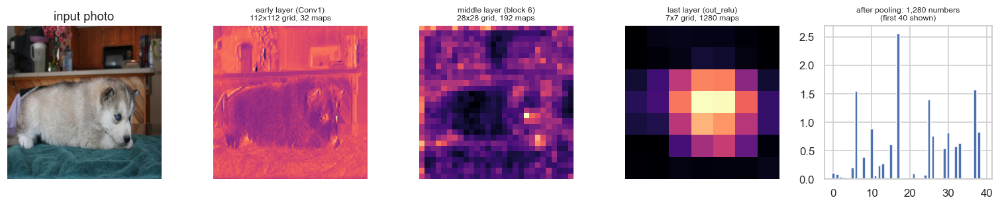

In [16]:
probe = X_full[np.where(sub.breed == 'Siberian_husky')[0][3]]
taps = {'early layer (Conv1)': 'Conv1', 'middle layer (block 6)': 'block_6_expand_relu', 'last layer (out_relu)': 'out_relu'}
base_m, pre_m = get_backbone('MobileNetV2')
probe_model = keras.Model(base_m.input, [base_m.get_layer(l).output for l in taps.values()])
maps = probe_model.predict(pre_m(probe[None].astype('float32')), verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(probe); axes[0].set_title('input photo'); axes[0].axis('off')
for ax, (title, m) in zip(axes[1:4], zip(taps, maps)):
    ax.imshow(m[0][..., :6].mean(-1) if 'early' in title else m[0].mean(-1), cmap='magma')
    ax.set_title(f'{title}\n{m.shape[1]}x{m.shape[2]} grid, {m.shape[3]} maps', fontsize=8); ax.axis('off')
axes[4].bar(range(40), maps[2][0].mean((0, 1))[:40], color='#4C72B0'); axes[4].set_title('after pooling: 1,280 numbers\n(first 40 shown)', fontsize=8)
plt.tight_layout(); save(fig, 'feature_maps.png'); plt.show()

**Takeaway:** this is the idea of a CNN made visible, and I did not train any of it.

* **Early layer (Conv1):** still looks like the photo. It picks out edges and outlines (the dog's outline, the shelf, the wooden cupboard).
* **Middle layer (block 6):** the picture is gone, it is blocky. Each square answers "is this texture or pattern present here?", like fur or wood grain.
* **Last layer (out_relu):** only a coarse 7 x 7 grid remains, and it is brightest on the dog. The frozen network already finds "where the dog is" on its own.
* **After pooling:** 1,280 numbers, a few of them large and most close to zero. Think of it as a checklist of "which of the 1,280 learned features are present in this photo".

That last list is all my dense head ever sees. So the head does not learn to see, it only learns which combinations of features mean which breed.

### Setting up the training code

All the experiments train the same small head, so I write a few helper functions once. A
neat trick makes this fast: because the base is frozen, it gives the **same 1,280 numbers for
the same photo every time**. So for every experiment without augmentation I run the photos
through the base once, save the numbers, and train the dense head directly on those. It is exactly
the same model as "frozen base + head", just without repeating identical work every epoch.
(Augmentation changes the photo every epoch, so that experiment has to run the real base each time.)

All runs use early stopping on the validation loss, so each one stops when it starts overfitting
and keeps the best weights it saw.

In [17]:
def get_feats(backbone, view):
    fp = CACHE / f'sub_{backbone}_{view}.npy'
    if fp.exists():
        return np.load(fp)
    t = time.time()
    f = embed({'full': X_full, 'crop': X_crop}[view], backbone)
    np.save(fp, f)
    print(f'  embedded {backbone}/{view} {f.shape} in {time.time() - t:.0f}s')
    return f

def fit_head(F, seed=SEED, max_epochs=MAX_EPOCHS, patience=8, **kw):
    """Train the dense head on cached features. Returns history + scores on the validation set."""
    head = build_head(F.shape[1], seed=seed, **kw)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    t = time.time()
    h = head.fit(F[tr], y[tr], validation_data=(F[va], y[va]), epochs=max_epochs, batch_size=32,
                 callbacks=[es], verbose=0)
    pred = head.predict(F[va], verbose=0).argmax(1)
    return dict(head=head, history=h.history, seconds=time.time() - t, epochs=len(h.history['loss']),
                best_epoch=int(np.argmin(h.history['val_loss'])) + 1, **{f'val_{k}': v for k, v in metrics(y[va], pred).items()})

def plot_history(hist, title, fname=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    ep = np.arange(1, len(hist['loss']) + 1)
    axes[0].plot(ep, hist['loss'], label='train'); axes[0].plot(ep, hist['val_loss'], label='validation')
    axes[0].axvline(np.argmin(hist['val_loss']) + 1, ls=':', color='grey', label='best epoch')
    axes[0].set(title=f'{title}: loss', xlabel='epoch', ylabel='loss'); axes[0].legend()
    axes[1].plot(ep, hist['accuracy'], label='train'); axes[1].plot(ep, hist['val_accuracy'], label='validation')
    axes[1].set(title=f'{title}: accuracy', xlabel='epoch', ylabel='accuracy'); axes[1].legend()
    plt.tight_layout()
    if fname: save(fig, fname)
    plt.show()

def summarize(runs, key):
    """Mean and standard deviation over the seeds, per setting."""
    df = pd.DataFrame([{key: r['setting'], 'val accuracy': r['val_accuracy'], 'val macro F1': r['val_macro_f1'],
                        'epochs run': r['epochs'], 'seconds': r['seconds']} for r in runs])
    g = df.groupby(key, sort=False)
    out = g.mean().round(3)
    out['F1 std'] = g['val macro F1'].std().round(3)
    return out

def plot_runs(runs, title, fname, seed=SEEDS[0]):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    colors = sns.color_palette('deep', len({r['setting'] for r in runs}))
    for c, setting in zip(colors, dict.fromkeys(r['setting'] for r in runs)):
        r = next(r for r in runs if r['setting'] == setting and r['seed'] == seed)
        ep = np.arange(1, len(r['history']['loss']) + 1)
        axes[0].plot(ep, r['history']['loss'], color=c, ls='--', alpha=.6)
        axes[0].plot(ep, r['history']['val_loss'], color=c, label=str(setting))
        axes[1].plot(ep, r['history']['accuracy'], color=c, ls='--', alpha=.6)
        axes[1].plot(ep, r['history']['val_accuracy'], color=c, label=str(setting))
    axes[0].set(title='loss (dashed = train, solid = validation)', xlabel='epoch'); axes[0].legend(fontsize=8)
    axes[1].set(title='accuracy (dashed = train, solid = validation)', xlabel='epoch'); axes[1].legend(fontsize=8)
    s = pd.DataFrame([{'setting': str(r['setting']), 'F1': r['val_macro_f1']} for r in runs])
    sns.barplot(data=s, x='setting', y='F1', errorbar='sd', ax=axes[2], palette=colors, capsize=.15)
    axes[2].set(title='validation macro F1 (mean, error bar = std over seeds)', xlabel='', ylim=(max(0, s.F1.min() - .1), 1))
    axes[2].tick_params(axis='x', labelsize=8)
    plt.suptitle(title, y=1.03); plt.tight_layout(); save(fig, fname); plt.show()

F_mnv2 = get_feats('MobileNetV2', 'full')
print('features ready', F_mnv2.shape)

  embedded MobileNetV2/full (1881, 1280) in 12s
features ready (1881, 1280)


### First run

One model with sensible default settings, to check that the whole pipeline works before I start
changing things: MobileNetV2 frozen, dense layer of 128 neurons, dropout 0.3, learning rate 0.001.

stopped after 14 epochs (best epoch 6), 1s
validation accuracy 0.741, macro F1 0.741


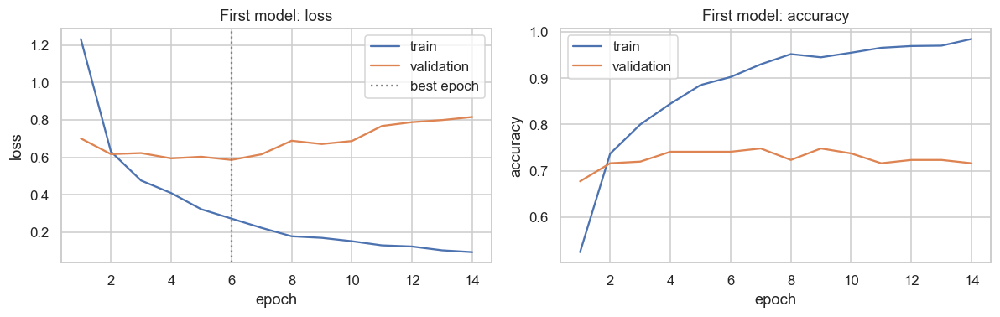

                                precision    recall  f1-score   support

                Siberian husky      0.667     0.500     0.571        28
                    Eskimo dog      0.419     0.591     0.491        22
                      malamute      0.800     0.741     0.769        27
                        collie      0.688     0.500     0.579        22
             Shetland sheepdog      0.808     0.913     0.857        23
                 Border collie      0.760     0.864     0.809        22
                    toy poodle      0.667     0.727     0.696        22
              miniature poodle      0.714     0.652     0.682        23
American Staffordshire terrier      0.840     0.875     0.857        24
     Staffordshire bullterrier      0.826     0.826     0.826        23
           miniature schnauzer      0.846     0.957     0.898        23
            standard schnauzer      0.947     0.783     0.857        23

                      accuracy                          0.741 

In [18]:
first = fit_head(F_mnv2, seed=SEED)
print(f"stopped after {first['epochs']} epochs (best epoch {first['best_epoch']}), {first['seconds']:.0f}s")
print(f"validation accuracy {first['val_accuracy']:.3f}, macro F1 {first['val_macro_f1']:.3f}")
plot_history(first['history'], 'First model', 'first_model_curves.png')

pred_first = first['head'].predict(F_mnv2[va], verbose=0).argmax(1)
print(classification_report(y[va], pred_first, target_names=names, digits=3))

**Takeaway:** the simple setup already works. A dense head on frozen MobileNetV2 features reaches **74.1% validation accuracy and 0.741 macro F1**, against 0.169 for raw pixels and 0.015 for the majority class. It stopped after 14 epochs with the best one at epoch 6, and it trained in about a second, because the features are cached.

Per breed, the schnauzers, Staffordshire pair, Shetland sheepdog and Border collie reach 0.81 to 0.90 F1. The weakest are **Eskimo dog (0.49), Siberian husky (0.57) and collie (0.58)**, which are the breeds with the most look-alike neighbours. So even before any experiment the errors already sit where the subset selection said they would.

### What overfitting looks like here

Before the experiments, one quick demonstration of what I am watching for in the curves. I train
a much bigger head (512 neurons) with **no dropout and no early stopping**, for 60 epochs.

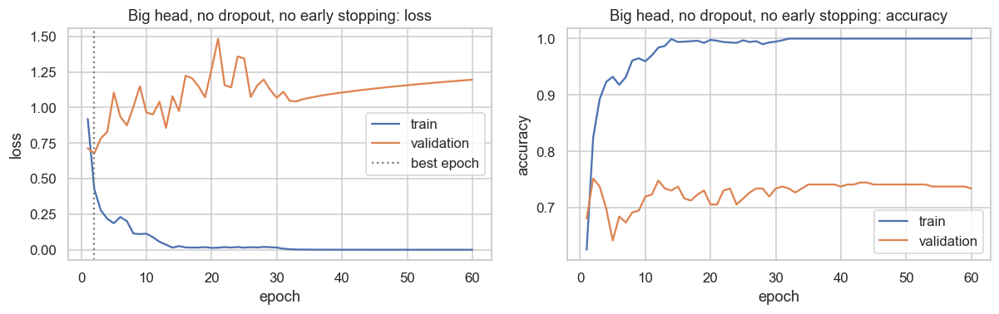

epoch with lowest val loss: 2 of 60
train accuracy at the end 1.000, validation accuracy at the end 0.734
validation loss: best 0.677, at the end 1.195


In [19]:
keras.utils.set_random_seed(SEED)
big = build_head(1280, hidden=512, dropout=0.0, lr=1e-3)
h_big = big.fit(F_mnv2[tr], y[tr], validation_data=(F_mnv2[va], y[va]), epochs=60, batch_size=32, verbose=0).history
plot_history(h_big, 'Big head, no dropout, no early stopping', 'overfitting_demo.png')
print(f"epoch with lowest val loss: {int(np.argmin(h_big['val_loss'])) + 1} of 60")
print(f"train accuracy at the end {h_big['accuracy'][-1]:.3f}, validation accuracy at the end {h_big['val_accuracy'][-1]:.3f}")
print(f"validation loss: best {min(h_big['val_loss']):.3f}, at the end {h_big['val_loss'][-1]:.3f}")

**Takeaway:** this is the textbook picture. Training loss goes to zero and training accuracy to 100%, so the network has memorised the 1,300 training photos. But the validation loss is lowest at **epoch 2** (0.68) and then climbs to about 1.2 by epoch 60, and the validation accuracy sits at about 0.73 and never improves.

Two things to notice. First, the validation loss can get much worse while the accuracy hardly changes. The model is still right about as often, but it gets more and more overconfident when it is wrong, and loss punishes that while accuracy does not see it. Second, this is the reason why every run in the experiments uses **early stopping** on validation loss. With 1,300 photos and 1,280 input features, a dense head can memorise everything very fast.

## 7. Experiments

The assignment is about training the dense layers on top of a pretrained base, so the experiments
look at the choices around that. I change **one thing at a time** and repeat every run with
several random seeds, because a single run can be lucky or unlucky. Results are always the
validation set, never the test set.

| Experiment | What changes | Everything else |
| --- | --- | --- |
| A. Learning rate | 0.1, 0.01, 0.001, 0.0001 | MobileNetV2, full photos |
| B. Backbone | MobileNetV2, ResNet50, EfficientNetB0 | best learning rate from A |
| C. Full photo vs crop | photo as given, or cropped to the dog box | best backbone |
| D. Augmentation | none, or random flips / rotations / zoom | best backbone, full photo |
| E. Fine-tuning | base frozen, or last conv layers unfrozen | everything from A to D |

Experiment E is the one place where I touch the pretrained weights, and only as an *extra*
on top of the main method (frozen base), not instead of it.

### Experiment A: learning rate

The learning rate is how big a step the optimiser takes when it updates the weights. Too big
and the loss bounces around, too small and training crawls. Same experiment as the ANN project,
but now on the dense head of the CNN.

               val accuracy  val macro F1  epochs run  seconds  F1 std
learning rate                                                         
lr=0.1                0.236         0.157      10.000    0.896   0.083
lr=0.01               0.710         0.695      12.333    1.044   0.032
lr=0.001              0.733         0.730      14.000    1.263   0.024
lr=0.0001             0.743         0.740      42.000    2.803   0.016


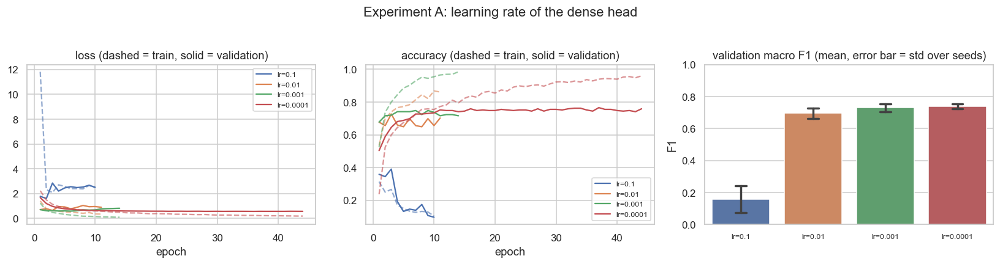

In [20]:
def run_set(F, setting, seeds=SEEDS, **kw):
    runs = []
    for s in seeds:
        r = fit_head(F, seed=s, **kw); r.update(setting=setting, seed=s); runs.append(r)
    return runs

LRS = [0.1, 0.01, 0.001, 0.0001]
lr_runs = [r for lr in LRS for r in run_set(F_mnv2, f'lr={lr}', lr=lr)]
print(summarize(lr_runs, 'learning rate'))
plot_runs(lr_runs, 'Experiment A: learning rate of the dense head', 'exp_learning_rate.png')

**Takeaway:** the same pattern as in the ANN project.

* **0.1 is broken** (F1 0.157). The loss bounces around and the accuracy gets worse than at the start of training, because every step overshoots.
* **0.01** works but is noisy (F1 0.695).
* **0.001 and 0.0001 are the best** (F1 0.730 and 0.740). The curves are smooth.

The difference between 0.001 and 0.0001 (0.010) is smaller than the spread between seeds (0.016 to 0.024), so honestly it is a tie. I use **0.0001** because it has the best mean and the smoothest curve, and the extra time costs nothing: it needs 42 epochs instead of 14, but the head still trains in about three seconds.

In the middle chart you can also see that with 0.0001 the training accuracy keeps creeping up to about 95% while the validation accuracy stays flat at around 0.75. That is overfitting again, and early stopping is what ends the run at the right moment.

### Experiment B: which pretrained backbone?

Same head, same learning rate, three different frozen bases:

* **MobileNetV2**: 2.3M parameters, 1,280 features. Small and fast.
* **ResNet50**: 23.6M parameters, 2,048 features. The classic, roughly 10x bigger.
* **EfficientNetB0**: 4.0M parameters, 1,280 features. Designed to be accurate for its size.

The question is whether a bigger base gives better features for telling breeds apart, or
whether the small one is enough. I use the best learning rate from experiment A.

learning rate used from here on: 0.0001


  embedded ResNet50/full (1881, 2048) in 50s


  embedded EfficientNetB0/full (1881, 1280) in 20s


                val accuracy  val macro F1  epochs run  seconds  F1 std  base parameters (M)
backbone                                                                                    
MobileNetV2            0.743         0.740      42.000    2.797   0.016                  2.3
ResNet50               0.727         0.721      34.667    2.871   0.006                 23.6
EfficientNetB0         0.734         0.727      40.333    2.780   0.007                  4.0


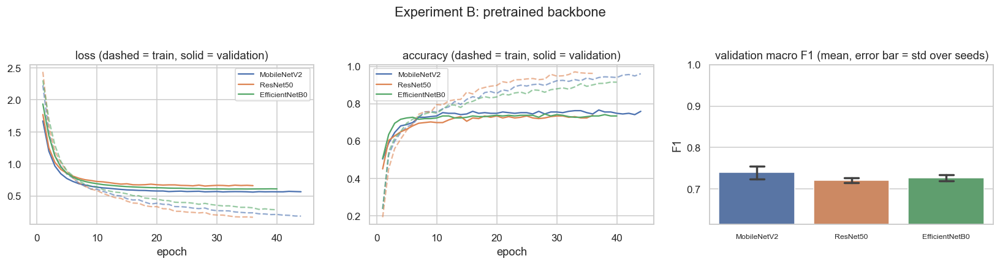

In [21]:
BEST_LR = float(summarize(lr_runs, 'lr').sort_values('val macro F1', ascending=False).index[0].split('=')[1])
print('learning rate used from here on:', BEST_LR)

BACKBONES = ['MobileNetV2', 'ResNet50', 'EfficientNetB0']
bb_runs = []
for b in BACKBONES:
    bb_runs += run_set(get_feats(b, 'full'), b, lr=BEST_LR)
n_params = {b: sum(int(np.prod(w.shape)) for w in get_backbone(b)[0].weights) for b in BACKBONES}
bb_table = summarize(bb_runs, 'backbone')
bb_table['base parameters (M)'] = pd.Series(n_params).div(1e6).round(1)
print(bb_table)
plot_runs(bb_runs, 'Experiment B: pretrained backbone', 'exp_backbone.png')

**Takeaway:** bigger is not better here.

MobileNetV2 scores **0.740**, EfficientNetB0 0.727 and ResNet50 0.721. ResNet50 has ten times more parameters (23.6M against 2.3M) and is the worst of the three. The gaps are about 0.02, which is about as big as the seed-to-seed spread for MobileNetV2 (0.016), so I cannot claim MobileNetV2 is really better. What I *can* say is that the bigger backbones give no gain.

My explanation (not tested): all three were trained on ImageNet, which contains these breeds, so all three already have good features. The limit is not how rich the features are, it is that the breeds are nearly identical and the labels are a bit noisy. A stronger network does not fix that. Practical side: MobileNetV2 is also the cheapest (embedding the photos took 13 to 20 seconds against 50 for ResNet50), so it is the obvious choice for a laptop.

### Experiment C: full photo or cropped to the dog?

From the EDA, the dog often covers only a small part of the photo, and the rest is lawn,
furniture and people. The bounding boxes let me test if the background is hurting. One
honest note before I run it: at deployment nobody hands the model a bounding box, so a crop
would need a separate dog detector first. So this experiment is *information about the
model*, and I decided beforehand that **the final model uses full photos** unless the crop
wins by a huge margin.

backbone used from here on: MobileNetV2


  embedded MobileNetV2/crop (1881, 1280) in 13s


                val accuracy  val macro F1  epochs run  seconds  F1 std
input                                                                  
full photo             0.743          0.74      42.000    2.848   0.016
cropped to dog         0.766          0.76      39.667    2.730   0.005


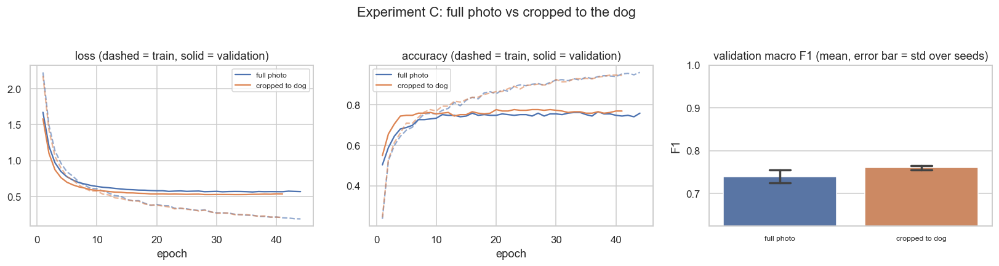

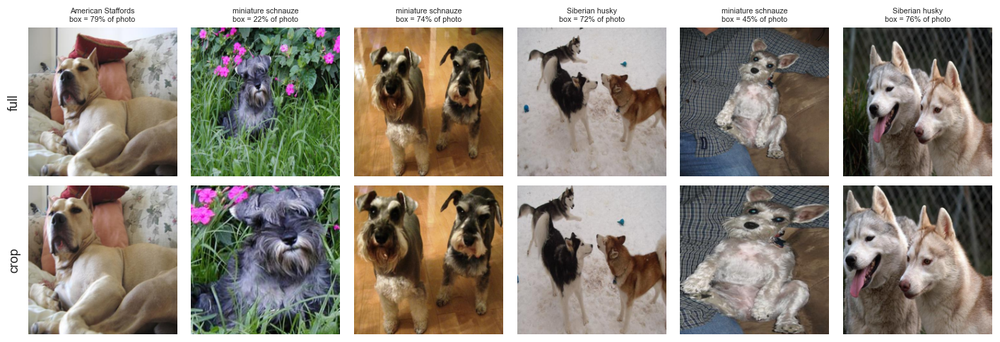

In [22]:
BEST_BB = bb_table['val macro F1'].idxmax()
print('backbone used from here on:', BEST_BB)
view_runs = run_set(get_feats(BEST_BB, 'full'), 'full photo', lr=BEST_LR) + \
            run_set(get_feats(BEST_BB, 'crop'), 'cropped to dog', lr=BEST_LR)
print(summarize(view_runs, 'input'))
plot_runs(view_runs, 'Experiment C: full photo vs cropped to the dog', 'exp_crop.png')

fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for c, i in enumerate(np.random.default_rng(3).choice(len(sub), 6, replace=False)):
    axes[0, c].imshow(X_full[i]); axes[1, c].imshow(X_crop[i])
    axes[0, c].set_title(f'{nice(sub.breed[i])[:18]}\nbox = {sub.box_frac[i]:.0%} of photo', fontsize=7)
for a in axes.ravel(): a.axis('off')
axes[0, 0].text(-0.05, .5, 'full', transform=axes[0, 0].transAxes, rotation=90, va='center', ha='right')
axes[1, 0].text(-0.05, .5, 'crop', transform=axes[1, 0].transAxes, rotation=90, va='center', ha='right')
plt.tight_layout(); save(fig, 'crop_examples.png'); plt.show()

**Takeaway:** cropping to the dog helps a little: **0.760 against 0.740** macro F1 (and the crop results are more stable across seeds, std 0.005 against 0.016). So the background does cost something, about two points.

Two reasons why I do not read more into it. First, two points is about the size of the noise with three seeds, so it is a hint and not proof. Second, the gain is small because the dog already covers 58% of a typical photo, and the frozen network mostly looks at the dog anyway (Grad-CAM in section 9 confirms this).

And as I wrote before running it: a crop needs a bounding box, and at deployment nobody gives the model one. You would need a dog detector first. Two points is not enough to justify that extra step, so **the final model uses full photos**.

### Experiment D: data augmentation

I only have about 1,400 training photos. Augmentation shows the network a slightly different
version of each photo every epoch (flipped, rotated a little, zoomed), so it cannot just
memorise the exact pixels. It is the CNN version of dropout.

Every transform is one that keeps the breed the same: a dog is still the same breed when it is
mirrored, a bit rotated or zoomed. I deliberately do **not** flip upside down (dogs are not
upside down in real photos) and I do not change colours much, because coat colour is part of
what separates breeds (a malamute is not a white Samoyed).

Because every epoch now has new photos, I cannot use saved features here. The photos go through
the real frozen base each epoch, which is slower. The base weights must not change: I check that
in code by fingerprinting all of them before and after training.

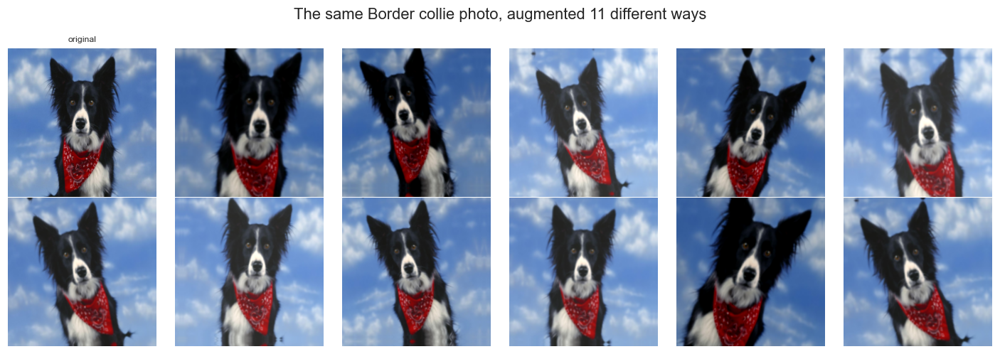

In [23]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.06),
    layers.RandomZoom((-0.2, 0.1)),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomBrightness(0.12, value_range=(0, 255)),
], name='augmentation')

def make_ds(X, labels, aug=False, shuffle=False, batch=32, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((X, labels))
    if shuffle:
        ds = ds.shuffle(len(X), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch)
    ds = ds.map(lambda a, b: (tf.cast(a, tf.float32), b))
    if aug:
        ds = ds.map(lambda a, b: (tf.clip_by_value(augment(a, training=True), 0, 255), b), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(1)

fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
pick = np.where(sub.breed == 'Border_collie')[0][2]
axes[0, 0].imshow(X_full[pick]); axes[0, 0].set_title('original', fontsize=8)
for ax in axes.ravel()[1:]:
    ax.imshow(np.clip(augment(X_full[pick][None].astype('float32'), training=True).numpy()[0], 0, 255).astype('uint8'))
for a in axes.ravel(): a.axis('off')
plt.suptitle('The same Border collie photo, augmented 11 different ways'); plt.tight_layout(); save(fig, 'augmentation_examples.png'); plt.show()

def fingerprint(base):
    return float(sum(np.abs(w.numpy()).sum() for w in base.weights))

     no augmentation seed 42: 14 epochs, val F1 0.715, 138s, base weights unchanged: True


     no augmentation seed 7: 14 epochs, val F1 0.729, 164s, base weights unchanged: True


     no augmentation seed 2024: 14 epochs, val F1 0.761, 162s, base weights unchanged: True


   with augmentation seed 42: 14 epochs, val F1 0.722, 188s, base weights unchanged: True


   with augmentation seed 7: 14 epochs, val F1 0.709, 188s, base weights unchanged: True


   with augmentation seed 2024: 14 epochs, val F1 0.728, 164s, base weights unchanged: True
                   val accuracy  val macro F1  epochs run  seconds  F1 std
augmentation                                                              
no augmentation           0.740         0.735        14.0  154.330   0.024
with augmentation         0.728         0.719        14.0  179.936   0.010


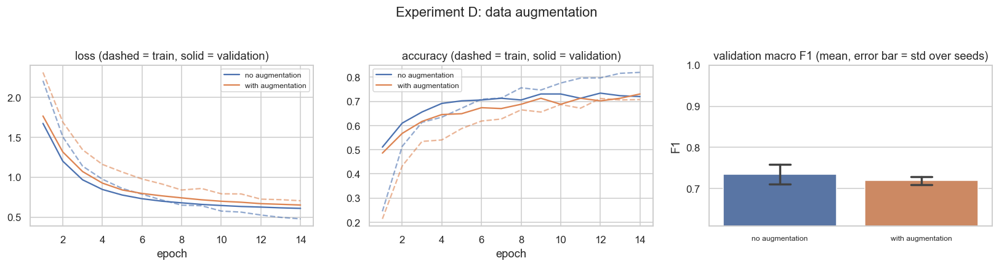

In [24]:
def fit_full(backbone, seed, aug, lr=BEST_LR, epochs=AUG_EPOCHS, patience=4):
    """Train the head through the real (frozen) base on raw photos, optionally augmented."""
    keras.utils.set_random_seed(seed)
    head = build_head(get_feats(backbone, 'full').shape[1], lr=lr, seed=seed)
    model, base = build_full(backbone, head)
    model.compile(keras.optimizers.Adam(lr), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    before = fingerprint(base)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    t = time.time()
    h = model.fit(make_ds(X_full[tr], y[tr], aug=aug, shuffle=True, seed=seed), validation_data=make_ds(X_full[va], y[va]),
                  epochs=epochs, callbacks=[es], verbose=0)
    pred = model.predict(make_ds(X_full[va], y[va]), verbose=0).argmax(1)
    assert fingerprint(base) == before, 'the pretrained weights changed!'
    return dict(head=head, model=model, base=base, history=h.history, seconds=time.time() - t, epochs=len(h.history['loss']),
                best_epoch=int(np.argmin(h.history['val_loss'])) + 1,
                **{f'val_{k}': v for k, v in metrics(y[va], pred).items()})

aug_runs = []
for aug in (False, True):
    for s in SEEDS:
        r = fit_full(BEST_BB, s, aug); r.update(setting='with augmentation' if aug else 'no augmentation', seed=s)
        aug_runs.append(r)
        print(f"  {r['setting']:>18} seed {s}: {r['epochs']} epochs, val F1 {r['val_macro_f1']:.3f}, {r['seconds']:.0f}s, base weights unchanged: True")
print(summarize(aug_runs, 'augmentation'))
plot_runs(aug_runs, 'Experiment D: data augmentation', 'exp_augmentation.png')

**Takeaway:** augmentation did not help. Validation macro F1 is **0.719 with augmentation and 0.735 without**. I expected the opposite, because augmentation is the standard cure for a small dataset. The difference is inside the noise (std 0.010 and 0.024), so the honest conclusion is "no evidence that it helps here", not "it hurts". The base weights were checked before and after every run and stayed exactly the same, as they should for a frozen base.

Possible reasons, which I did not test:

1. **The pretrained features are already robust.** ImageNet networks were themselves trained with flips and crops, so the 1,280 features change little when a photo is mirrored or zoomed.
2. **Not enough epochs.** Every one of these six runs used all 14 epochs, so none was stopped by early stopping. With the small learning rate and harder, changing data, the augmented head may simply not have converged yet. This is a limit of my setup.
3. **Zooming can cut away what matters.** When the zoom crops off the face or the ears, the information that separates two look-alike breeds is gone, and the label is now harder to guess.

Augmentation is also slower, because each epoch has to push the photos through the real base (about 180 seconds per run, against 3 seconds with cached features).

### Experiment E: fine-tuning (the optional extra)

Everything so far kept the pretrained layers frozen, which is what the assignment asks for.
Fine-tuning goes one step further: after the head is trained, I **unfreeze the last 30
layers of the base** (the ones that detect the most specific, high level features) and train
them together with the head, using a tiny learning rate (0.00001) so I nudge the pretrained
weights instead of wrecking them. I keep the BatchNorm layers frozen, which is the standard
advice when fine-tuning on a small dataset.

This is slower on a CPU, so I use two seeds instead of three. The starting point for each seed is
the trained frozen model from experiment D (same seed, with the better augmentation setting).

augmentation used for fine-tuning: False


  seed 42: frozen F1 0.715 -> fine-tuned F1 0.726 (1,676,236 trainable weights, 82s)


  seed 7: frozen F1 0.729 -> fine-tuned F1 0.733 (1,676,236 trainable weights, 71s)
                         val accuracy  val macro F1  epochs run  seconds  F1 std
setting                                                                         
frozen base                     0.727         0.722        14.0  150.735   0.010
last 30 layers unfrozen         0.736         0.730         5.5   76.481   0.005


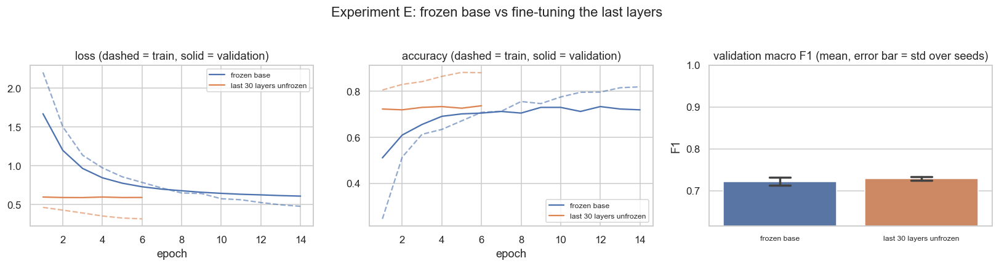

In [25]:
USE_AUG = (summarize(aug_runs, 'a').loc['with augmentation', 'val macro F1'] >
           summarize(aug_runs, 'a').loc['no augmentation', 'val macro F1'])
print('augmentation used for fine-tuning:', USE_AUG)

def finetune(r, seed, n_unfreeze=30, lr=1e-5, epochs=FT_EPOCHS, patience=3, aug=USE_AUG):
    model, base, head = r['model'], r['base'], r['head']
    base.trainable = True
    for l in base.layers[:-n_unfreeze]:
        l.trainable = False
    for l in base.layers[-n_unfreeze:]:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    n_train = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    model.compile(keras.optimizers.Adam(lr), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    t = time.time()
    h = model.fit(make_ds(X_full[tr], y[tr], aug=aug, shuffle=True, seed=seed), validation_data=make_ds(X_full[va], y[va]),
                  epochs=epochs, callbacks=[es], verbose=0)
    pred = model.predict(make_ds(X_full[va], y[va]), verbose=0).argmax(1)
    return dict(model=model, history=h.history, seconds=time.time() - t, epochs=len(h.history['loss']), n_trainable=n_train,
                best_epoch=int(np.argmin(h.history['val_loss'])) + 1,
                **{f'val_{k}': v for k, v in metrics(y[va], pred).items()})

frozen_ref, ft_runs, ft_models = [], [], {}
for s in FT_SEEDS:
    base_run = next(r for r in aug_runs if r['seed'] == s and r['setting'] == ('with augmentation' if USE_AUG else 'no augmentation'))
    frozen_ref.append(dict(base_run, setting='frozen base'))   # already trained in experiment D, reuse it
    r = finetune(base_run, s); r.update(setting='last 30 layers unfrozen', seed=s); ft_runs.append(r)
    print(f"  seed {s}: frozen F1 {base_run['val_macro_f1']:.3f} -> fine-tuned F1 {r['val_macro_f1']:.3f} "
          f"({r['n_trainable']:,} trainable weights, {r['seconds']:.0f}s)")
ft_all = frozen_ref + ft_runs
print(summarize(ft_all, 'setting'))
plot_runs(ft_all, 'Experiment E: frozen base vs fine-tuning the last layers', 'exp_finetune.png')

**Takeaway:** fine-tuning gives a tiny gain, **0.730 against 0.722** macro F1 (+0.008). The spread between seeds is 0.005 to 0.010, so this is within the noise.

It went into the final recipe only because I decided beforehand to use it "if the mean validation score is higher", and it was, by a hair. I want to be clear that this is not strong evidence. What I can say is that the run stopped early (5.5 epochs on average), because the validation loss started to rise quickly. That makes sense: I unfroze 1.7 million weights (against 165,000 in the head) and only have 1,300 training photos, so the network starts memorising almost right away.

I think the reason that fine-tuning does little is that MobileNetV2 has already seen dogs in ImageNet, so there is little to adapt. I would expect a bigger gain for a dataset that looks very different from ImageNet, like X-rays or MRI scans.

### Summary of all experiments

One table with everything, so the comparison is easy to read.

                                            F1  F1_std  accuracy
experiment      setting                                         
A learning rate lr=0.1                   0.157   0.083     0.236
                lr=0.01                  0.695   0.032     0.710
                lr=0.001                 0.730   0.024     0.733
                lr=0.0001                0.740   0.016     0.743
B backbone      MobileNetV2              0.740   0.016     0.743
                ResNet50                 0.721   0.006     0.727
                EfficientNetB0           0.727   0.007     0.734
C input         full photo               0.740   0.016     0.743
                cropped to dog           0.760   0.005     0.766
D augmentation  no augmentation          0.735   0.024     0.740
                with augmentation        0.719   0.010     0.728
E fine-tuning   frozen base              0.722   0.010     0.727
                last 30 layers unfrozen  0.730   0.005     0.736


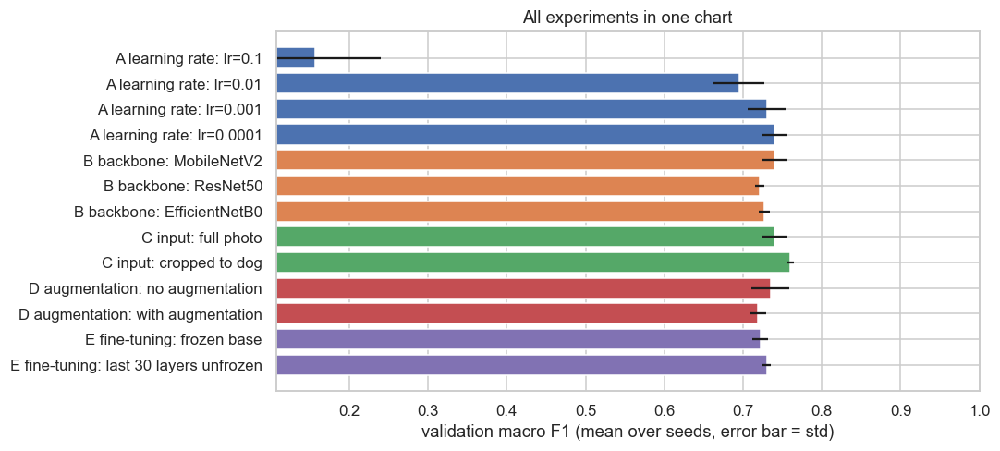

In [26]:
def collect(name, runs):
    d = pd.DataFrame([{'experiment': name, 'setting': r['setting'], 'val macro F1': r['val_macro_f1'],
                       'val accuracy': r['val_accuracy']} for r in runs])
    return d
allr = pd.concat([collect('A learning rate', lr_runs), collect('B backbone', bb_runs), collect('C input', view_runs),
                  collect('D augmentation', aug_runs), collect('E fine-tuning', ft_all)])
summary = allr.groupby(['experiment', 'setting'], sort=False).agg(F1=('val macro F1', 'mean'), F1_std=('val macro F1', 'std'),
                                                                   accuracy=('val accuracy', 'mean')).round(3)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 4.6))
cols = dict(zip(summary.index.get_level_values(0).unique(), sns.color_palette('deep', 5)))
lab = [f'{e[0]}: {e[1]}' for e in summary.index]
ax.barh(lab[::-1], summary.F1.values[::-1], xerr=summary.F1_std.fillna(0).values[::-1],
        color=[cols[e[0]] for e in summary.index][::-1])
ax.set(xlim=(max(0, summary.F1.min() - .05), 1), xlabel='validation macro F1 (mean over seeds, error bar = std)',
       title='All experiments in one chart')
plt.tight_layout(); save(fig, 'experiment_summary.png'); plt.show()

**Takeaway:** apart from the broken learning rate of 0.1, every setting lands between **0.72 and 0.76** macro F1. That whole range (0.04) is about two to four times the seed-to-seed spread, so most of the differences in this table are small. The only thing that moves the score visibly is cropping to the dog (+0.02), and that is not usable in practice without a detector.

So, same lesson as in the ANN project: once the frozen features are good and the learning rate is in a sensible range, tuning does not get much more out of the model. The ceiling of about 0.73 to 0.76 is set by the data (breeds that look the same and some wrong labels), not by the settings. To go beyond it I would need better labels or more informative photos, not more experiments.

## 8. Final model and test set evaluation

### The final recipe

I combine the choices the validation experiments supported:

* backbone: the winner of experiment B
* input: full photos (decided beforehand, see experiment C)
* learning rate: the winner of experiment A
* augmentation and fine-tuning: only if they helped on the validation set

I retrain this model with seed 42 and then run it **once** on the test set, which no experiment has
used. I also score the first default model from section 6 on the test set, so I can see
whether all the experiments were worth it.

final recipe: backbone=MobileNetV2, lr=0.0001, augmentation=False, fine-tuning=True


final model, validation: {'accuracy': 0.734, 'macro_f1': 0.729}


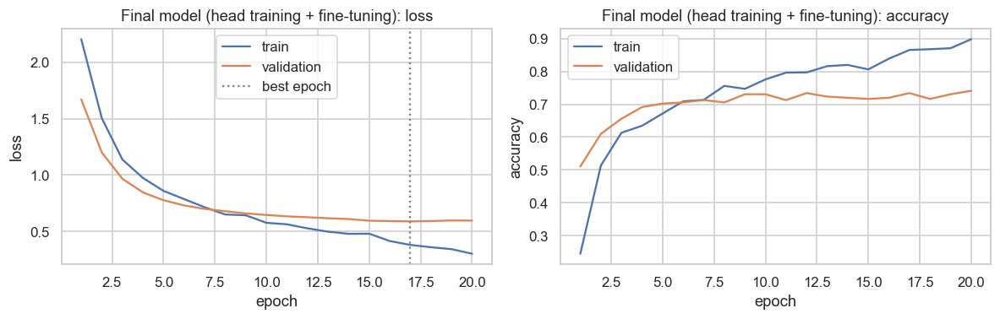

In [27]:
USE_FT = (summarize(ft_all, 's').loc['last 30 layers unfrozen', 'val macro F1'] >
          summarize(ft_all, 's').loc['frozen base', 'val macro F1'])
print(f'final recipe: backbone={BEST_BB}, lr={BEST_LR}, augmentation={USE_AUG}, fine-tuning={USE_FT}')

final = fit_full(BEST_BB, SEED, USE_AUG)
hist_final = {k: list(v) for k, v in final['history'].items()}
if USE_FT:
    ft = finetune(final, SEED)
    for k in hist_final:
        hist_final[k] += ft['history'][k]
    final['model'] = ft['model']
final_model, final_base, final_head = final['model'], final['base'], final['head']
final_val = metrics(y[va], final_model.predict(make_ds(X_full[va], y[va]), verbose=0).argmax(1))
print('final model, validation:', {k: round(v, 3) for k, v in final_val.items()})
plot_history(hist_final, 'Final model (head training' + (' + fine-tuning' if USE_FT else '') + ')', 'final_model_curves.png')

In [28]:
# ---- the one and only look at the test set ----
Xte = make_ds(X_full[te], y[te])
proba_te = final_model.predict(Xte, verbose=0)
pred_te = proba_te.argmax(1)
y_te = y[te]

test_scores = pd.DataFrame({
    'majority class': metrics(y_te, maj.predict(Xp[te])),
    'logistic regression on raw pixels': metrics(y_te, pix.predict(sc.transform(Xp[te]))),
    'first model (frozen MobileNetV2 + head, defaults)': metrics(y_te, first['head'].predict(F_mnv2[te], verbose=0).argmax(1)),
    'final model': metrics(y_te, pred_te),
}).T
print(f'test set: {len(te)} photos the model has never seen\n')
print(test_scores.round(3))
print()
print(classification_report(y_te, pred_te, target_names=names, digits=3))

test set: 283 photos the model has never seen

                                                   accuracy  macro_f1
majority class                                        0.102     0.015
logistic regression on raw pixels                     0.131     0.128
first model (frozen MobileNetV2 + head, defaults)     0.703     0.707
final model                                           0.703     0.706

                                precision    recall  f1-score   support

                Siberian husky      0.536     0.517     0.526        29
                    Eskimo dog      0.500     0.455     0.476        22
                      malamute      0.645     0.741     0.690        27
                        collie      0.556     0.682     0.612        22
             Shetland sheepdog      0.778     0.583     0.667        24
                 Border collie      0.857     0.857     0.857        21
                    toy poodle      0.696     0.727     0.711        22
              miniature p

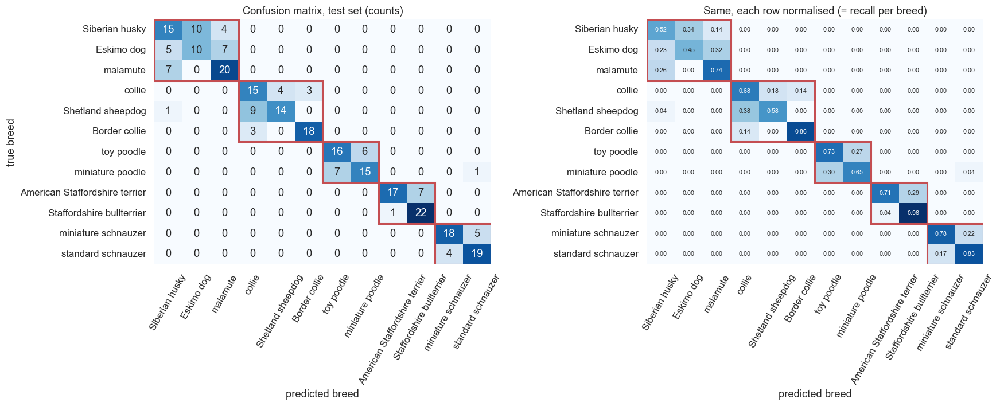

84 mistakes in total. 82 of them (98%) are between two breeds of the same look-alike group.
If mistakes were spread randomly, only 14% would be within a group.

most common confusions (true -> predicted):
  Siberian husky -> Eskimo dog: 10
  Shetland sheepdog -> collie: 9
  American Staffordshire terrier -> Staffordshire bullterrier: 7
  miniature poodle -> toy poodle: 7
  Eskimo dog -> malamute: 7
  malamute -> Siberian husky: 7


In [29]:
cm = confusion_matrix(y_te, pred_te)
cmn = confusion_matrix(y_te, pred_te, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(16, 6.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names, ax=axes[0], cbar=False)
axes[0].set(title='Confusion matrix, test set (counts)', xlabel='predicted breed', ylabel='true breed')
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', xticklabels=names, yticklabels=names, ax=axes[1], cbar=False, annot_kws={'size': 7})
axes[1].set(title='Same, each row normalised (= recall per breed)', xlabel='predicted breed', ylabel='')
# draw the look-alike groups
pos = 0
for g, bs in GROUPS.items():
    for a in axes:
        a.add_patch(plt.Rectangle((pos, pos), len(bs), len(bs), fill=False, ec='#C44E52', lw=2))
    pos += len(bs)
for a in axes: a.tick_params(axis='x', rotation=60)
plt.tight_layout(); save(fig, 'confusion_matrix.png'); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
errs = off.sum()
within = sum(off[i, j] for i in range(N) for j in range(N) if i != j and GROUP_OF[CLASSES[i]] == GROUP_OF[CLASSES[j]])
print(f'{errs} mistakes in total. {within} of them ({within / max(errs, 1):.0%}) are between two breeds of the same look-alike group.')
print(f'If mistakes were spread randomly, only {sum(1 for i in range(N) for j in range(N) if i != j and GROUP_OF[CLASSES[i]] == GROUP_OF[CLASSES[j]]) / (N * (N - 1)):.0%} would be within a group.')
print('\nmost common confusions (true -> predicted):')
for c, (i, j) in zip(range(6), np.dstack(np.unravel_index(np.argsort(-off.ravel()), off.shape))[0]):
    if off[i, j]: print(f'  {names[i]} -> {names[j]}: {off[i, j]}')

**Takeaway:** on 283 test photos that the model has never seen, the final model reaches **70.3% accuracy and 0.706 macro F1**. The baselines: majority class 10.2% accuracy, raw pixel logistic regression 13.1%. So the pretrained features lift the score from near-guessing to about seven in ten, and the plain frozen-base model (only the 6.8% dense head trained, which is exactly what the assignment asks for) already gets the same score, see point 1.

Three honest points:

1. **The final model is not better than the first one.** The plain first model (frozen base, default settings) scores 0.703 accuracy and 0.707 macro F1 on the test set. The final model scores 0.703 and 0.706. All the experiments together did not improve the model in a measurable way. The experiments did teach me why (section 7), which is also a result, but I should not pretend the tuning paid off.
2. **The test score is 3 points below the validation score** (0.734 on validation). The test set is small: one photo is 0.35% and the standard error of an accuracy of 0.70 on 283 photos is about 2.7 points. So this gap is about one standard error and is normal noise.
3. **The best breeds** are Border collie (0.857 F1), Staffordshire bullterrier (0.846) and American Staffordshire terrier (0.810). **The worst** are Eskimo dog (0.476), Siberian husky (0.526) and collie (0.612), again the same ones as in the first run and in the 120-breed analysis.

### Reading the confusion matrix

The red squares are my look-alike groups. The most important fact: **82 of the 84 mistakes (98%) are between breeds of the same group.** If the mistakes were random, only 14% would be. So my prediction from section 3 holds: the model never confuses a poodle with a husky. Only two photos crossed groups (a Shetland sheepdog called a Siberian husky, and a miniature poodle called a standard schnauzer). The model knows what *kind* of dog it sees, and only struggles with which sibling.

Within the groups, there are three different kinds of mistakes:

* **The northern spitz group is the worst.** Recall is 0.52 for husky, 0.45 for Eskimo dog and 0.74 for malamute. The errors go in every direction (husky to Eskimo dog 10, Eskimo dog to malamute 7, malamute to husky 7). The model has not found anything that reliably separates these three, and as the sample photos showed, neither could I.
* **One-directional mistakes.** Shetland sheepdogs are called collies 9 times, but collies are called Shetland sheepdogs only 4 times. American Staffordshire terriers are called Staffordshire bullterriers 7 times, the other way only once. The model has a favourite: Staffordshire bullterrier has a recall of 0.96 but a precision of only 0.76, because it collects the mistakes of the other breed. This is typical when one breed looks like a "typical version" of the other.
* **Symmetric mistakes in the size pairs.** Toy against miniature poodle (6 and 7) and miniature against standard schnauzer (5 and 4) are mixed up about equally in both directions. These breeds mostly differ in **size**, and a photo of a single dog without a reference does not show size. No image model can fully fix that, it is a limit of the input, not of the model.

And remember the duplicate check: the same photo was filed under both breeds for exactly these pairs. Part of the "errors" here is the dataset not agreeing with itself.

### Right and wrong test photos

The numbers only go so far. Here are real test photos. The title shows the true breed, what the model
predicted and how sure it was. For the mistakes I show the **most confident wrong answers**,
because those are the most informative ones.

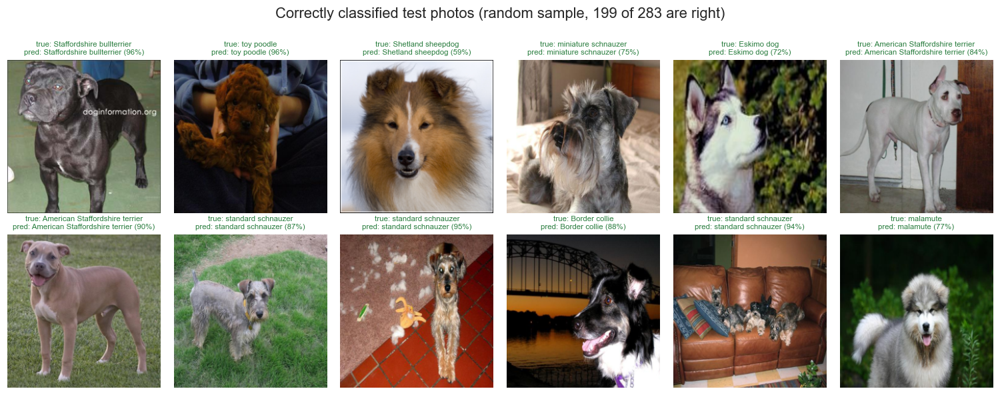

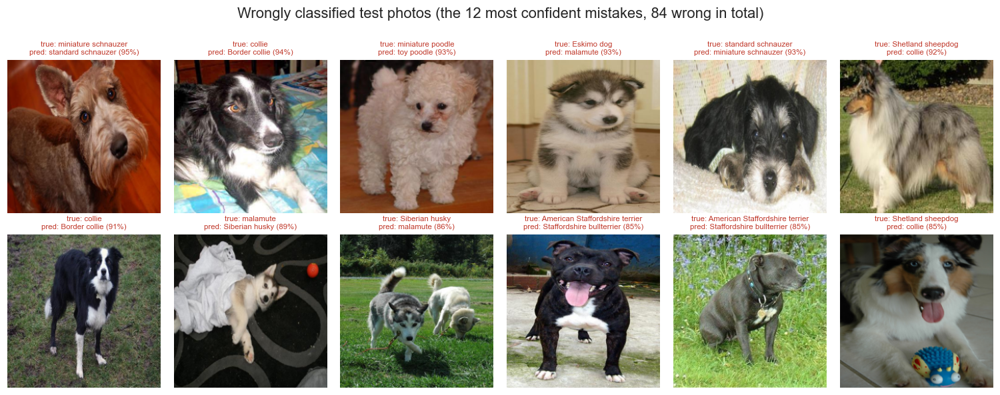

In [30]:
conf_te = proba_te.max(1)
right = np.where(pred_te == y_te)[0]
wrong = np.where(pred_te != y_te)[0]
rng = np.random.default_rng(1)
show_right = rng.choice(right, 12, replace=False)
show_wrong = wrong[np.argsort(-conf_te[wrong])][:12]

def gallery(ids, title, fname, cols=6):
    rows = int(np.ceil(len(ids) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.3 * cols, 2.75 * rows))
    for ax in axes.ravel(): ax.axis('off')
    for ax, k in zip(axes.ravel(), ids):
        ax.imshow(X_full[te[k]])
        ok = pred_te[k] == y_te[k]
        ax.set_title(f'true: {names[y_te[k]]}\npred: {names[pred_te[k]]} ({conf_te[k]:.0%})', fontsize=7.5, color='#2a7d3f' if ok else '#c0392b')
    plt.suptitle(title, y=1.0); plt.tight_layout(); save(fig, fname); plt.show()

gallery(show_right, f'Correctly classified test photos (random sample, {len(right)} of {len(te)} are right)', 'examples_right.png')
gallery(show_wrong, f'Wrongly classified test photos (the 12 most confident mistakes, {len(wrong)} wrong in total)', 'examples_wrong.png')

**Takeaway:** the right answers are the clear, typical photos: a face looking at the camera, a standing dog on grass, good light. The interesting part is the wrong answers, and what I see is that **many of the most confident mistakes are not obviously the model's fault**:

* The photo labelled *collie* that the model calls *Border collie* (94%) shows a black and white dog that looks like a Border collie (or an Australian shepherd) to me.
* The *Shetland sheepdog* that becomes *collie* (92% and 85%) looks like a small, rough collie.
* The *Eskimo dog* puppy called *malamute* (93%) is a fluffy puppy, and puppies of these breeds look alike.
* The two *American Staffordshire terriers* called *Staffordshire bullterriers* are the near-identical pair.

So the model is confident because the photo really looks typical for the breed it names, and the label may be the questionable one. This has a practical meaning: a confidence of 85 to 95% on a wrong answer means the confidence score is **not** a reliable warning. For a shelter I would show the top two breeds, not one confident answer.

## 9. Does the model look at the dog? (Grad-CAM)

Accuracy does not tell me *why* the model is right. A model can cheat: if all husky photos
have snow in them, it can learn "snow = husky" and never look at the dog. **Grad-CAM** shows
where the model looked. It takes the last convolutional feature map (the 7 x 7 grid), weighs each
map by how much it pushed the predicted class up, and paints the result over the photo.
Bright means "this area mattered for the answer".

And because this dataset has bounding boxes, I can measure it: what share of the heat falls
inside the dog's box? If the model looked everywhere equally, that share would just equal
the share of the photo that the box covers. A share much larger than that means the model
really looks at the dog.

share of Grad-CAM heat inside the dog box:   0.769
share of the photo the box covers (chance):  0.614
  correct predictions: heat inside 0.782  (box covers 0.613)
  wrong predictions:   heat inside 0.738  (box covers 0.618)
photos where more than half the heat is inside the box: 86%


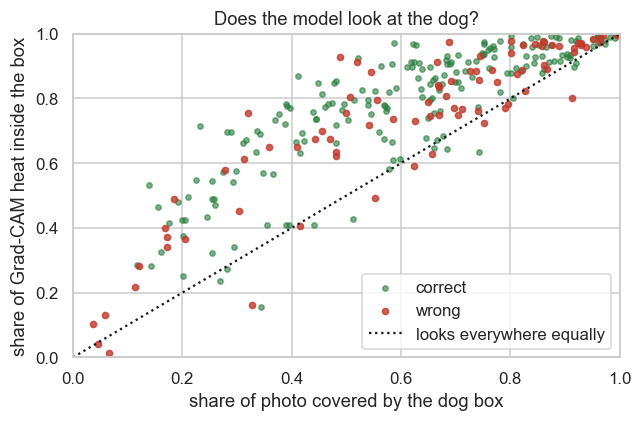

In [31]:
def gradcam(model, base, imgs_uint8):
    """Grad-CAM for the predicted class of every image. Returns heatmaps (B,224,224) and predicted classes."""
    _, pre = get_backbone(BEST_BB)
    head = model.get_layer('head')
    x = tf.convert_to_tensor(imgs_uint8.astype('float32'))
    with tf.GradientTape() as tape:
        fmap = base(pre(x), training=False)
        tape.watch(fmap)
        probs = head(tf.reduce_mean(fmap, axis=(1, 2)), training=False)
        cls = tf.argmax(probs, axis=1)
        score = tf.gather(probs, cls, batch_dims=1)
    g = tape.gradient(score, fmap)
    cam = tf.nn.relu(tf.reduce_sum(fmap * tf.reduce_mean(g, axis=(1, 2), keepdims=True), axis=-1))
    cam = tf.image.resize(cam[..., None], (224, 224))[..., 0].numpy()
    cam = cam / (cam.max(axis=(1, 2), keepdims=True) + 1e-8)
    return cam, cls.numpy()

# box mask in the 224x224 squashed coordinates
def box_mask(r):
    m = np.zeros((224, 224), bool)
    m[int(r.y0 / r.h * 224):int(np.ceil(r.y1 / r.h * 224)), int(r.x0 / r.w * 224):int(np.ceil(r.x1 / r.w * 224))] = True
    return m

cams = np.concatenate([gradcam(final_model, final_base, X_full[te[i:i + 32]])[0] for i in range(0, len(te), 32)])
masks = np.stack([box_mask(sub.iloc[i]) for i in te])
inside = (cams * masks).sum((1, 2)) / (cams.sum((1, 2)) + 1e-8)
area = masks.mean((1, 2))
is_right = pred_te == y_te
print(f'share of Grad-CAM heat inside the dog box:   {inside.mean():.3f}')
print(f'share of the photo the box covers (chance):  {area.mean():.3f}')
print(f'  correct predictions: heat inside {inside[is_right].mean():.3f}  (box covers {area[is_right].mean():.3f})')
print(f'  wrong predictions:   heat inside {inside[~is_right].mean():.3f}  (box covers {area[~is_right].mean():.3f})')
print(f'photos where more than half the heat is inside the box: {(inside > .5).mean():.0%}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(area[is_right], inside[is_right], s=12, alpha=.6, label='correct', color='#2a7d3f')
ax.scatter(area[~is_right], inside[~is_right], s=16, alpha=.8, label='wrong', color='#c0392b')
ax.plot([0, 1], [0, 1], 'k:', label='looks everywhere equally')
ax.set(xlabel='share of photo covered by the dog box', ylabel='share of Grad-CAM heat inside the box',
       title='Does the model look at the dog?', xlim=(0, 1), ylim=(0, 1)); ax.legend()
plt.tight_layout(); save(fig, 'gradcam_inside_box.png'); plt.show()

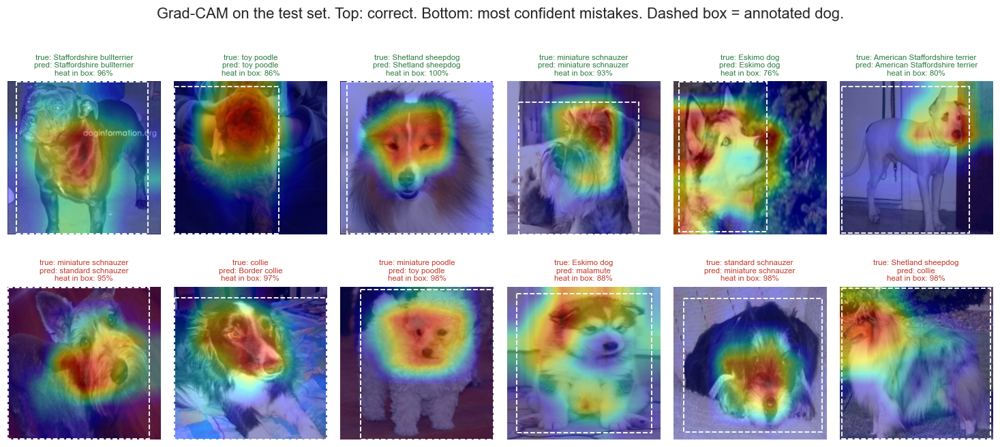


small dogs (box < 25% of photo, n=26): accuracy 0.577, heat inside box 0.354
big dogs   (box >= 25% of photo, n=257): accuracy 0.716, heat inside box 0.811


In [32]:
def overlay(i, ax):
    ax.imshow(X_full[te[i]]); ax.imshow(cams[i], cmap='jet', alpha=.42)
    r = sub.iloc[te[i]]
    ax.add_patch(plt.Rectangle((r.x0 / r.w * 224, r.y0 / r.h * 224), (r.x1 - r.x0) / r.w * 224, (r.y1 - r.y0) / r.h * 224,
                               fill=False, ec='white', lw=1.2, ls='--'))
    ax.set_title(f'true: {names[y_te[i]]}\npred: {names[pred_te[i]]}\nheat in box: {inside[i]:.0%}', fontsize=7.5,
                 color='#2a7d3f' if pred_te[i] == y_te[i] else '#c0392b')
    ax.axis('off')

fig, axes = plt.subplots(2, 6, figsize=(13.5, 6.4))
for ax, i in zip(axes[0], show_right[:6]): overlay(i, ax)
for ax, i in zip(axes[1], show_wrong[:6]): overlay(i, ax)
plt.suptitle('Grad-CAM on the test set. Top: correct. Bottom: most confident mistakes. Dashed box = annotated dog.', y=1.0)
plt.tight_layout(); save(fig, 'gradcam_examples.png'); plt.show()

# what does it do when the dog is small?
small = area < 0.25
print(f'\nsmall dogs (box < 25% of photo, n={small.sum()}): accuracy {is_right[small].mean():.3f}, heat inside box {inside[small].mean():.3f}')
print(f'big dogs   (box >= 25% of photo, n={(~small).sum()}): accuracy {is_right[~small].mean():.3f}, heat inside box {inside[~small].mean():.3f}')

**Takeaway:** the model mostly looks at the dog, and that means it is not cheating with the background.

* On average **77% of the heat is inside the dog's box, while the box only covers 61% of the photo.** In the scatter plot almost all points are above the dotted "looks everywhere equally" line, and in 86% of the test photos more than half the heat is inside the box.
* The heat sits on faces, the chest and the coat, which is where the differences between breeds are.
* **The mistakes are not caused by looking at the wrong thing.** Wrong predictions have a similar share inside the box (74% against 78% for correct ones), and the most confident mistakes have 88 to 98%. The model looks at the right dog and picks the wrong sibling. That matches the confusion matrix.

Two warnings. **Small dogs are the weak spot:** when the dog covers less than a quarter of the photo (26 test photos), only 35% of the heat is inside the box and the accuracy is 0.58, against 0.72 for bigger dogs. The 7 x 7 grid is coarse and with only 26 photos I would not over-interpret it, but it fits with the crop experiment. And a small thing I noticed and did not test: in the Staffordshire photos with the "doginformation.org" watermark, the heat partly covers the watermark. If one breed had many more watermarked photos, the model could use it as a shortcut. With the data I have, I cannot say either way.

## 10. Discussion and limitations

### What worked

* **Letting the data choose the subset.** Measuring that the full task is too easy (84.3%) and then selecting the hard breeds from the similarity and the confusions gave a problem that is actually interesting, and a confusion matrix with structure.
* **Checking for duplicates.** Like removing the leaky columns in the ANN project, this was the most valuable data step. The same photo under two breeds would have made the evaluation unfair.
* **Caching the frozen features.** Because the base is frozen, I could run the learning rate, backbone and crop experiments with three seeds each in seconds, and only the slow experiments (augmentation and fine-tuning) needed the real network.
* **Comparing with baselines.** The raw pixel baseline (13% on test) shows that the gain really comes from the pretrained convolutional features, and the first-model-against-final-model comparison stopped me from overselling the tuning.

### What surprised me

* Augmentation, fine-tuning and a bigger backbone did not help. I expected at least one of them to. The most likely explanation is that the limit of this task is in the data (look-alike breeds and some wrong labels), not in the model.
* Many of the confident mistakes look defensible when I look at the photo myself.

### Limitations

1. **The ImageNet overlap.** The photos come from ImageNet and so did the pretraining. The network has very likely seen these breeds, and maybe some of these exact photos. The scores are probably optimistic compared with new photos. A fair test would use dog photos from outside ImageNet, for example real shelter photos.
2. **Mixed breeds.** I only used breeds that have a clear standard. Most shelter dogs are mixes, and those are not covered at all. So this is a study of the *method*, not a shelter tool.
3. **Label noise.** I removed copies, but single wrongly labelled photos are invisible to my check. That puts a ceiling below 100% on any score.
4. **Small test set.** 283 photos gives a standard error of about 2.7 points, and the experiments use two or three seeds. Differences of about 0.02 (which is nearly all of them) should not be trusted, and that is how I have tried to read them.
5. **I chose the subset with MobileNetV2.** The 12 breeds are hard *for that network*. Experiment B suggests the other two backbones find them about equally hard, but I did not test other subsets.
6. **Setup limits.** The augmentation runs stopped at the 14-epoch limit instead of by early stopping, so augmentation may deserve a longer run. Fine-tuning used one learning rate and one layer count. Everything ran on a CPU. Photos were squashed to squares. Grad-CAM uses a coarse 7 x 7 grid.
7. **Test set use.** All decisions were made on the validation set, and the test set was used once for the final model. I also scored the first default model on it, so the test set was used for two models, but nothing was changed afterwards.

### Conclusion

**Can a pretrained network with untouched convolutional layers and a small dense head learn to separate look-alike breeds from about two thousand photos?** Partly. It reaches about 70% on 12 breeds where guessing gives 8%, and the pure frozen-base version, where only 6.8% of the parameters are trained, scores as well as the fine-tuned one. It almost never confuses breeds from different groups. But inside a group it keeps mixing up siblings, because the breeds are nearly identical (husky, Eskimo dog, malamute), or differ mostly in size (poodles, schnauzers), or because the dataset labels them inconsistently.

The most useful lessons for me as an applied engineer were not about the architecture:

* Test whether your problem is actually hard before you build the model.
* Check the data for duplicates and label conflicts before you trust any score.
* Compare the tuned model against the first simple one. Here the tuning did not pay off, and the honest result is to say so.

**What I would do next:** add photos from outside ImageNet as a cleaner test set, remove or fix the noisy labels, show the top two breeds with their confidence instead of one answer, and try a higher input resolution so small dogs are not lost.

## 11. References

**Dataset**

1. Khosla, A., Jayadevaprakash, N., Yao, B. and Fei-Fei, L. (2011). *Novel dataset for
   Fine-Grained Image Categorization*. First Workshop on Fine-Grained Visual Categorization,
   CVPR 2011. http://vision.stanford.edu/aditya86/ImageNetDogs/
2. Deng, J. et al. (2009). *ImageNet: A large-scale hierarchical image database*. CVPR 2009.

**Models and methods**

3. Sandler, M. et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR 2018.
4. He, K. et al. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR 2016.
5. Tan, M. and Le, Q. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML 2019.
6. Selvaraju, R. et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*. ICCV 2017.
7. Keras documentation, *Transfer learning & fine-tuning*. https://keras.io/guides/transfer_learning/

**Context**

8. Voith, V. L. et al. (2013). *Comparison of visual and DNA breed identification of dogs and inter-observer
   reliability*. American Journal of Sociological Research, 3(2), 17-29.